# 📊 TOBIG'S 6주차 과제 — 데이터 시각화

세션에서 다룬 내용(*Fundamentals of Data Visualization*, Claus O. Wilke)을 직접 코드로 확인해 보는 과제입니다.

### 진행 방법
- 라이브러리는 **plotnine**을 사용합니다. R의 **ggplot2** 문법을 파이썬으로 옮긴 라이브러리라서 `ggplot(데이터, aes(...)) + geom_*()` 구조가 똑같습니다.
- 코드의 `____` 부분을 채워 셀을 실행하세요.
- 🔧 **고치기** 문제는 주어진 *나쁜 차트*를 세션 내용에 맞게 고치는 문제입니다.
- 📝 표시가 있는 문제는 **✍️ 답:** 칸에 2~3문장으로 답을 작성하세요.
- Colab의 한글 폰트 문제를 피하기 위해 **그래프 안의 라벨은 영어로** 작성합니다.

### 목차
1. 시각적 속성과 스케일
2. 위치 스케일 (선형 / 로그)
3. 색상 스케일 (정성적 / 강조 / 순차적 / 발산형)
4. 수량 데이터 (막대, 묶은·누적 막대, 점 도표, 순서형 범주)
5. 분포 데이터 (히스토그램, 밀도 도표, 여러 분포 비교)
6. 종합 문제

## 0. 준비

In [38]:
# Colab에는 plotnine이 기본 설치되어 있습니다. 없다는 에러가 나면 아래 줄의 주석을 풀고 실행하세요.
# !pip install -q plotnine

import numpy as np
import pandas as pd
from plotnine import *
from plotnine.data import mtcars, mpg, midwest, txhousing, faithful, penguins

# 세션에서 소개한 Okabe-Ito 정성적 팔레트 (색각 이상이 있어도 구분하기 쉬운 팔레트)
OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

theme_set(theme_minimal() + theme(figure_size=(7, 4.5)))

## 1. 시각적 속성과 스케일

세션에서 **시각적 속성 = 값을 정량화 → 그래픽으로 표현**하는 것이고, **스케일**은 값과 시각적 속성을 연결하는 방식이라고 배웠습니다.
슬라이드 7의 자동차 산점도는 `mtcars` 데이터로 그린 그래프이며, **5개의 스케일**을 사용합니다.

### 문제 1-1 (빈칸)
`mtcars`로 슬라이드 7의 그래프를 재현하세요.

| 변수 | 의미 | 시각적 속성 |
|---|---|---|
| `disp` | 배기량 | x 위치 |
| `mpg` | 연비 | y 위치 |
| `hp` | 마력 | 색상 |
| `wt` | 무게 | 크기 |
| `cyl` | 실린더 수 | 모양 |

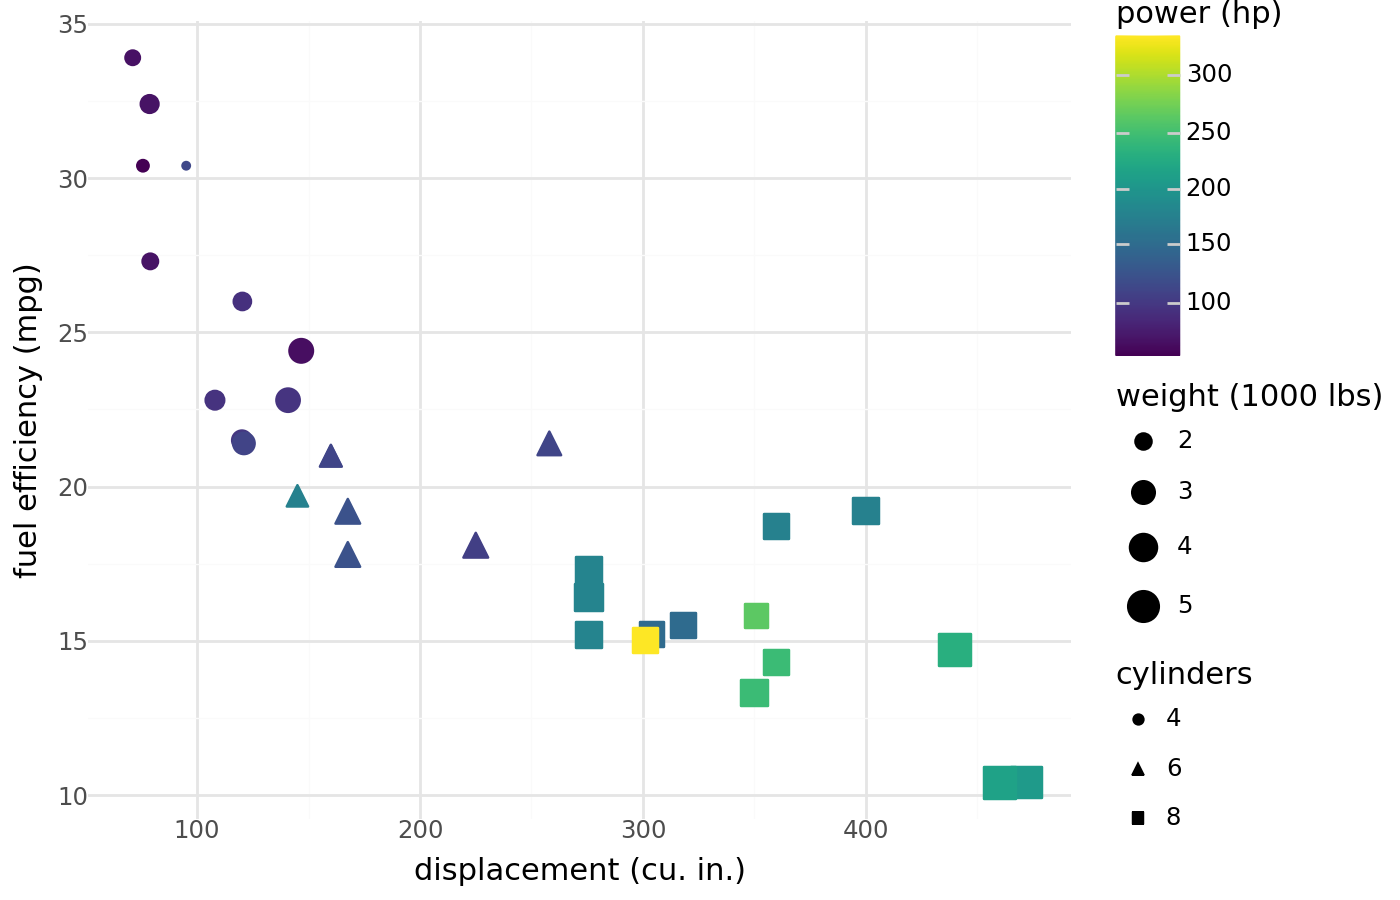

In [39]:
(
    ggplot(mtcars, aes(x="disp", y="mpg",
                       color="hp",          # TODO: 마력
                       size="wt",           # TODO: 무게
                       shape="factor(cyl)"))         # TODO: 실린더 수 (힌트: 범주형으로 바꿔야 합니다)
    + geom_point()
    + scale_color_cmap("viridis")
    + labs(x="displacement (cu. in.)", y="fuel efficiency (mpg)",
           color="power (hp)", size="weight (1000 lbs)", shape="cylinders")
)

### 문제 1-2 📝
`shape`에 `"cyl"` 대신 `"factor(cyl)"`을 넣어야 하는 이유는 무엇일까요? **모양**이라는 시각적 속성이 표현할 수 있는 데이터 종류와 연결해서 설명하세요.

**✍️ 답:** cyl은 범주를 구분하는 값이다. 모양은 연속적인 크기를 표현하는 것이 아니기 때문에 factor(cyl)로 범주형으로 바꿔 모양에 매핑해야 한다.

## 2. 위치 스케일 — 로그 스케일

슬라이드 13에서는 텍사스 카운티 인구를 **중간값으로 나눈 비율**로 그렸습니다.
선형 스케일에서는 몇몇 대도시 때문에 나머지 카운티가 바닥에 깔려 보이지 않았고, 로그 스케일을 쓰자 전체 구조가 드러났습니다.

여기서는 미국 중서부 5개 주, 437개 카운티 데이터인 `midwest`로 같은 분석을 해봅니다.

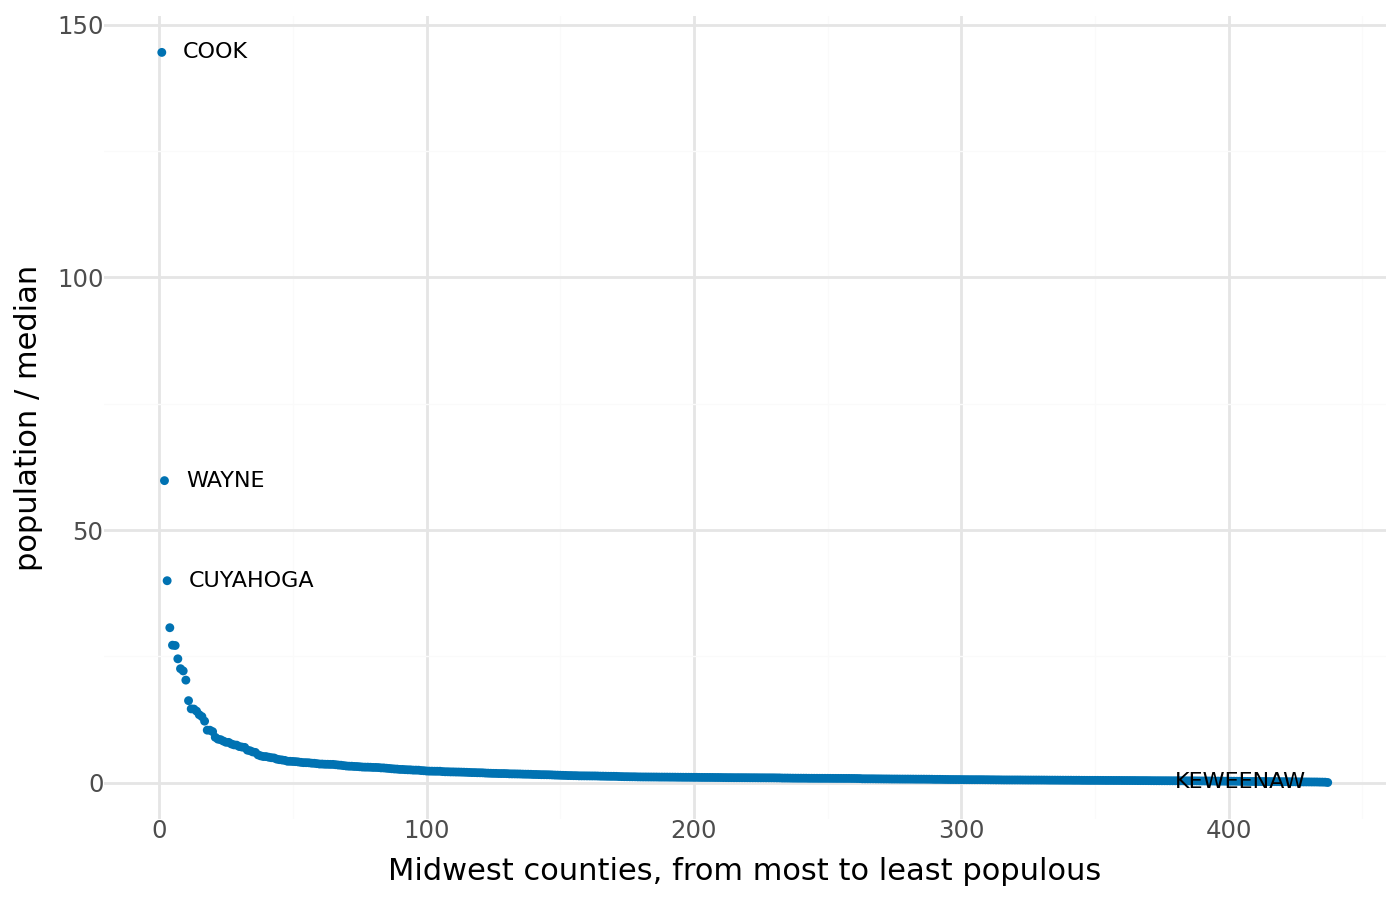

In [40]:
# 인구를 중간값으로 나눈 비율, 인구가 많은 순으로 순위 매기기
county = midwest[["county", "state", "poptotal"]].copy()
county["ratio"] = county["poptotal"] / county["poptotal"].median()
county = county.sort_values("ratio", ascending=False).reset_index(drop=True)
county["rank"] = np.arange(1, len(county) + 1)

# 라벨을 붙일 카운티: 상위 3개(점 오른쪽에 표시) + 최하위 1개(점 왼쪽에 표시)
p_linear = (
    ggplot(county, aes(x="rank", y="ratio"))
    + geom_point(size=0.8, color="#0072B2")
    + geom_text(aes(label="county"), data=county.head(3), ha="left", nudge_x=8, size=8)
    + geom_text(aes(label="county"), data=county.tail(1), ha="right", nudge_x=-8, size=8)
    + labs(x="Midwest counties, from most to least populous", y="population / median")
)
p_linear

### 문제 2-1 (빈칸)
위 그래프는 선형 스케일이라 대부분의 카운티가 0 근처에 몰려 있습니다. y축을 **로그 스케일**로 바꾸고, 중간값(비율 = 1)에 점선 기준선을 추가하세요.

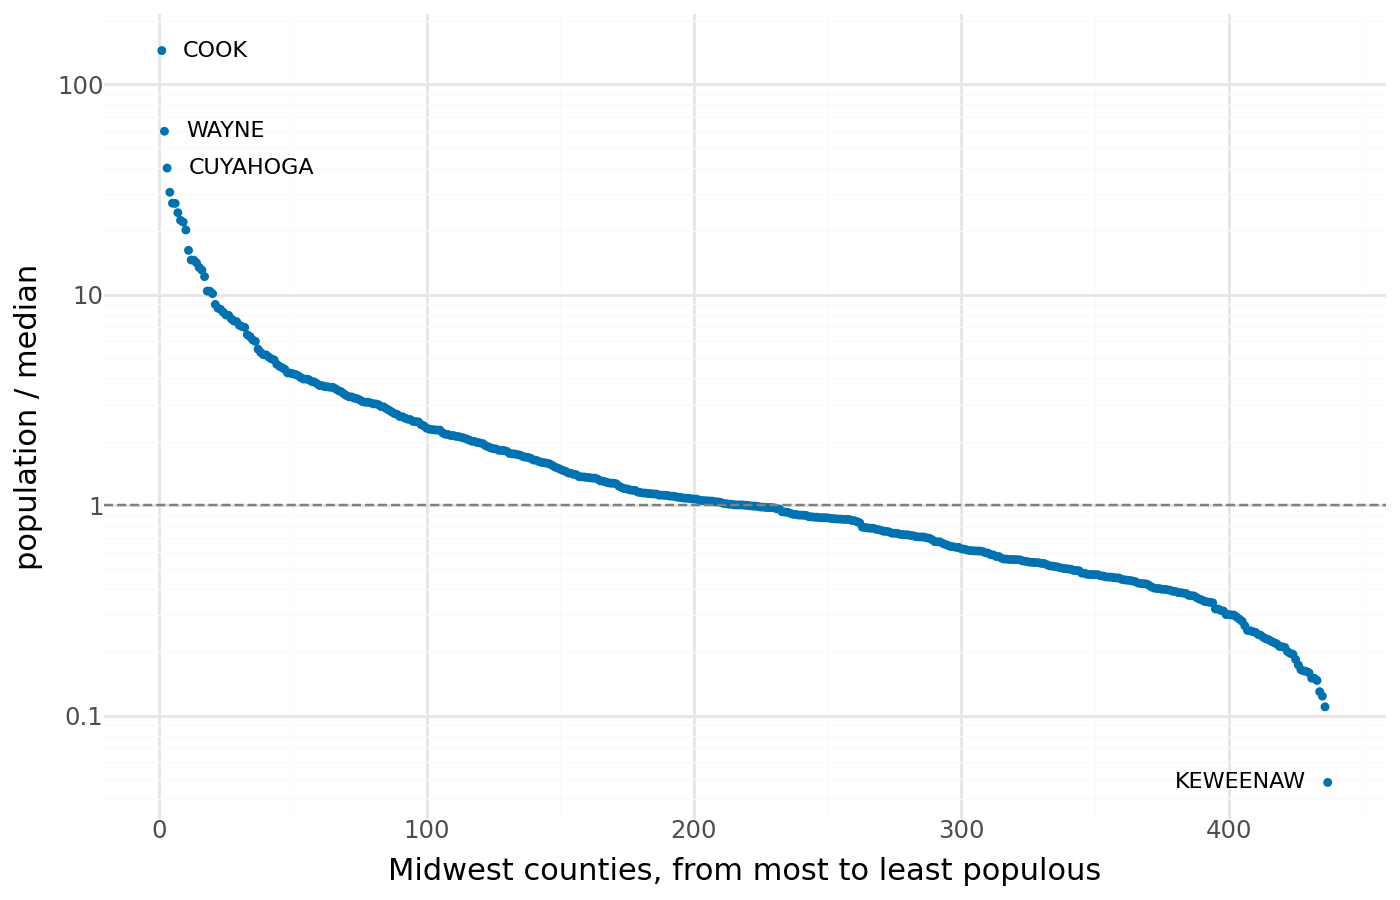

In [41]:
(
    p_linear
    + scale_y_log10()                                                    # TODO: y축 로그 스케일
    + geom_hline(yintercept=1, linetype="dashed", color="gray")   # TODO: 중간값 위치
)

### 문제 2-2 🔧 고치기
슬라이드 11의 *wrong* 사례처럼, 아래 그래프는 **데이터와 축 제목이 맞지 않습니다.**
무엇이 잘못됐는지 찾고, 원본 데이터를 로그 스케일로 올바르게 그리도록 고치세요.

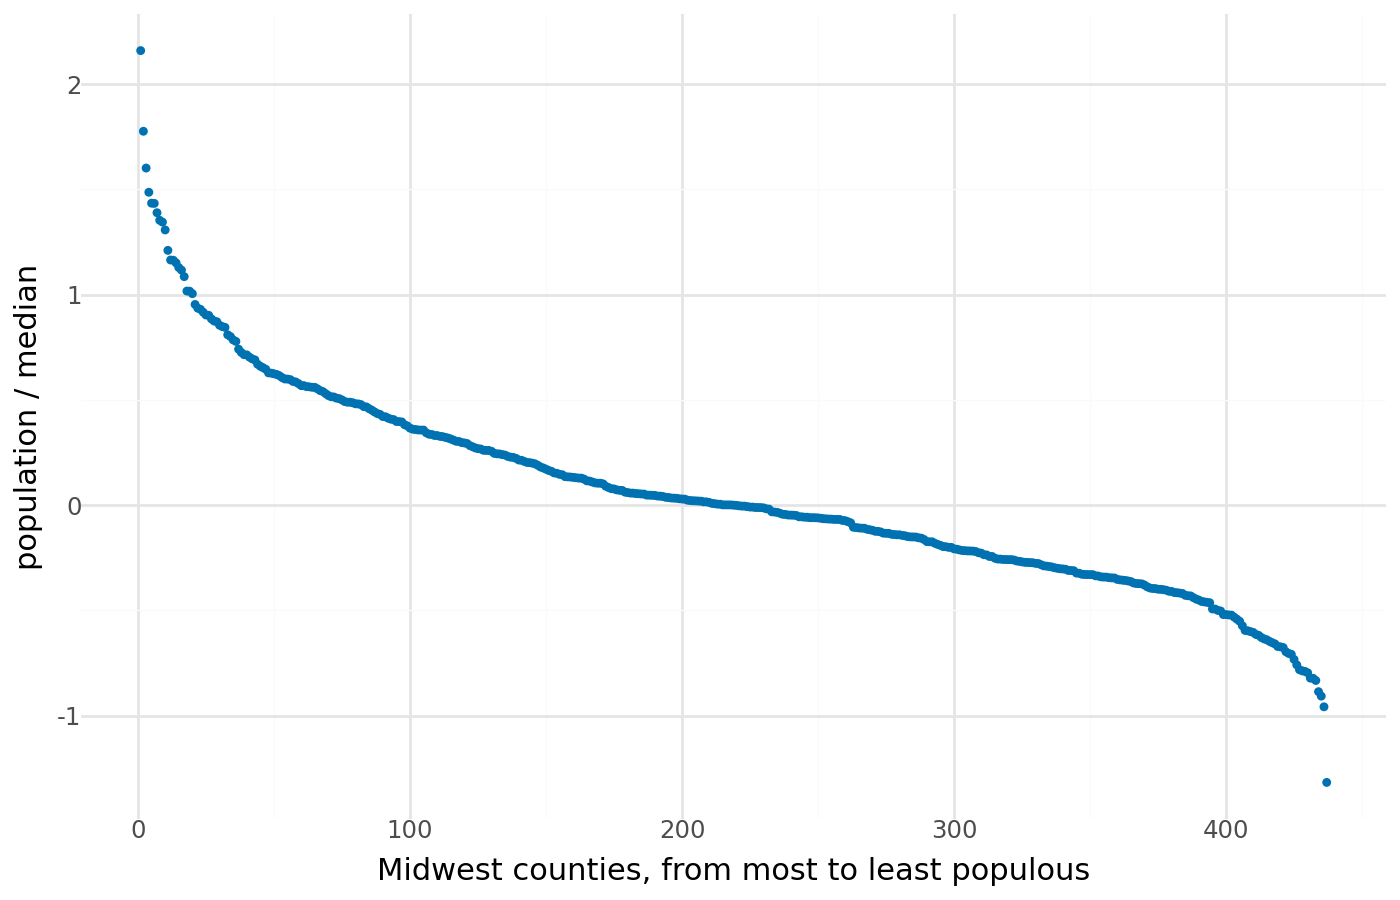

In [42]:
# ❌ 잘못된 그래프 (그대로 두세요)
county["log_ratio"] = np.log10(county["ratio"])

(
    ggplot(county, aes(x="rank", y="log_ratio"))
    + geom_point(size=0.8, color="#0072B2")
    + labs(x="Midwest counties, from most to least populous", y="population / median")
)

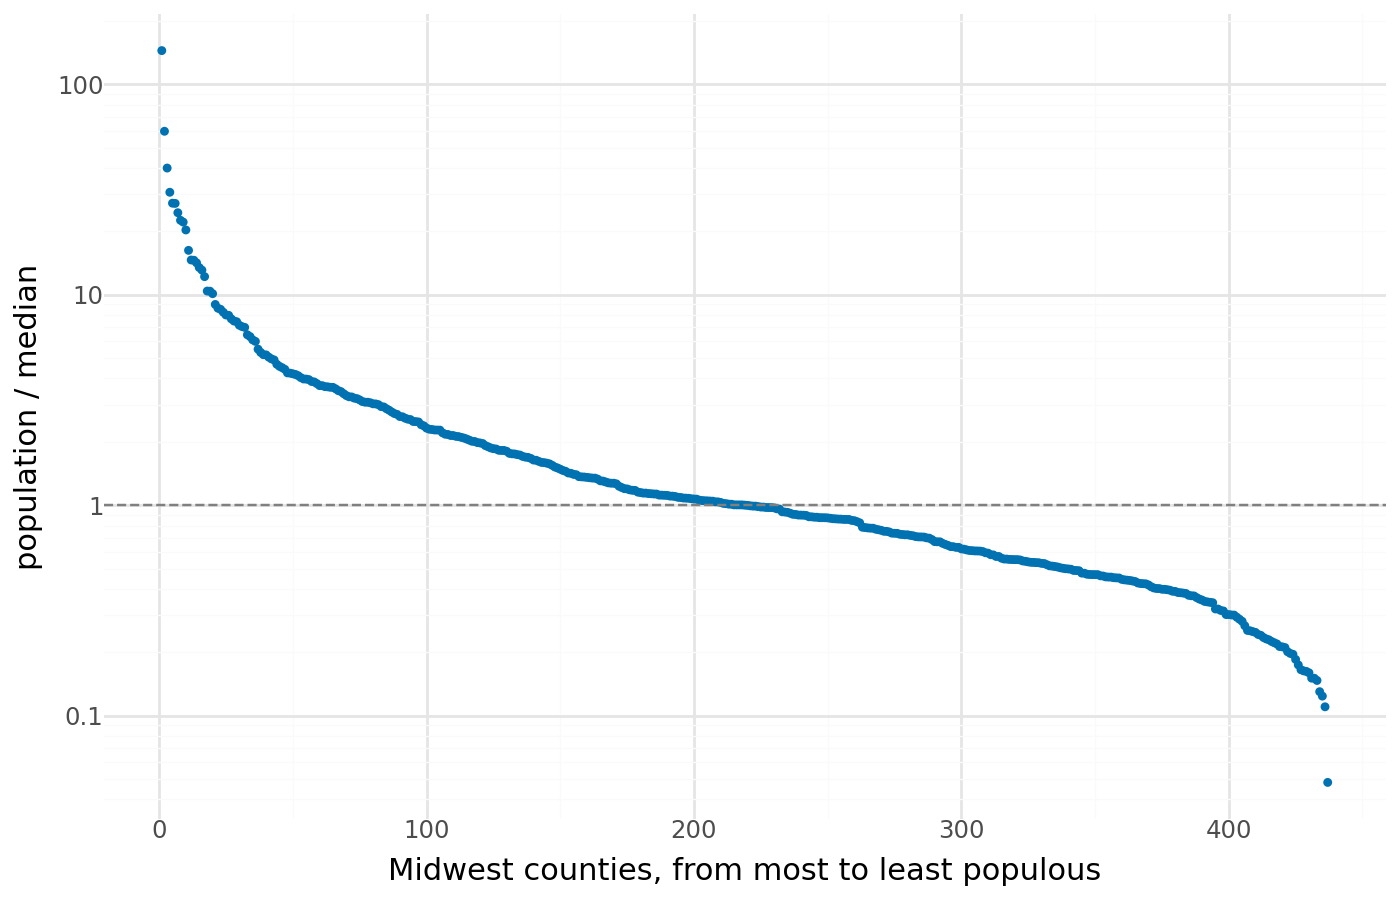

In [43]:
# ✅ 고친 그래프를 작성하세요
# 무엇이 잘못됐는지 주석으로 적어 주세요:
#
# 잘못된 점: 원본 데이터에 로그 변환을 적용했지만,
# y축에는 원래 비율인 것처럼 표시하여 혼동을 줄 수 있다.
# 수정 방법: 원본 ratio를 사용하고 y축에 로그 스케일을 적용한다.

(
    ggplot(county, aes(x="rank", y="ratio"))
    + geom_point(size=0.8, color="#0072B2")
    + scale_y_log10()
    + geom_hline(
        yintercept=1,
        linetype="dashed",
        color="gray"
    )
    + labs(
        x="Midwest counties, from most to least populous",
        y="population / median"
    )
)


### 문제 2-3 📝
인구 데이터가 아니라 **0이 포함된 데이터**(예: 연간 사고 건수)를 로그 스케일로 그리면 어떤 문제가 생길까요? 세션에서 소개한 대안 스케일은 무엇인가요?

**✍️ 답:**로그 스케일은 0이 포함된 데이터를 그대로 표현할 수 없다. 이를 해결하기 위해 0 근처에서는 선형 스케일을 사용하고, 큰 값에서는 로그 스케일을 사용하는 symlog 스케일을 대안으로 사용할 수 있다.

## 3. 색상 스케일

세션에서 배운 색상의 세 가지 목적은 다음과 같습니다.
1. **데이터 그룹 구분**: 정성적 스케일
2. **데이터 값 표현**: 순차적 스케일, 발산형 스케일
3. **특정 값 강조**: 강조 스케일

### 준비: 제조사별 평균 고속도로 연비
`mpg` 데이터의 제조사에 **제조국** 정보를 붙입니다.

In [44]:
COUNTRY = {
    "audi": "Germany", "volkswagen": "Germany",
    "chevrolet": "USA", "dodge": "USA", "ford": "USA", "jeep": "USA",
    "lincoln": "USA", "mercury": "USA", "pontiac": "USA",
    "honda": "Japan", "nissan": "Japan", "subaru": "Japan", "toyota": "Japan",
    "hyundai": "Korea", "land rover": "UK",
}

maker = mpg.groupby("manufacturer", as_index=False, observed=True)["hwy"].mean()
maker["country"] = maker["manufacturer"].map(COUNTRY)
maker.head()

,manufacturer,hwy,country
0,audi,26.444444,Germany
1,chevrolet,21.894737,USA
2,dodge,17.945946,USA
3,ford,19.360000,USA
4,honda,32.555556,Japan


### 문제 3-1 (빈칸) — 정성적 스케일
슬라이드 21처럼 **연비 순으로 정렬한 가로 막대 그래프**를 그리고, 막대 색으로 **제조국**을 구분하세요.
- 막대 순서: `reorder(manufacturer, hwy)`를 쓰면 hwy 값 순서로 정렬됩니다.
- 색상: 순서가 없는 그룹이므로 `OKABE_ITO` 팔레트를 사용합니다.

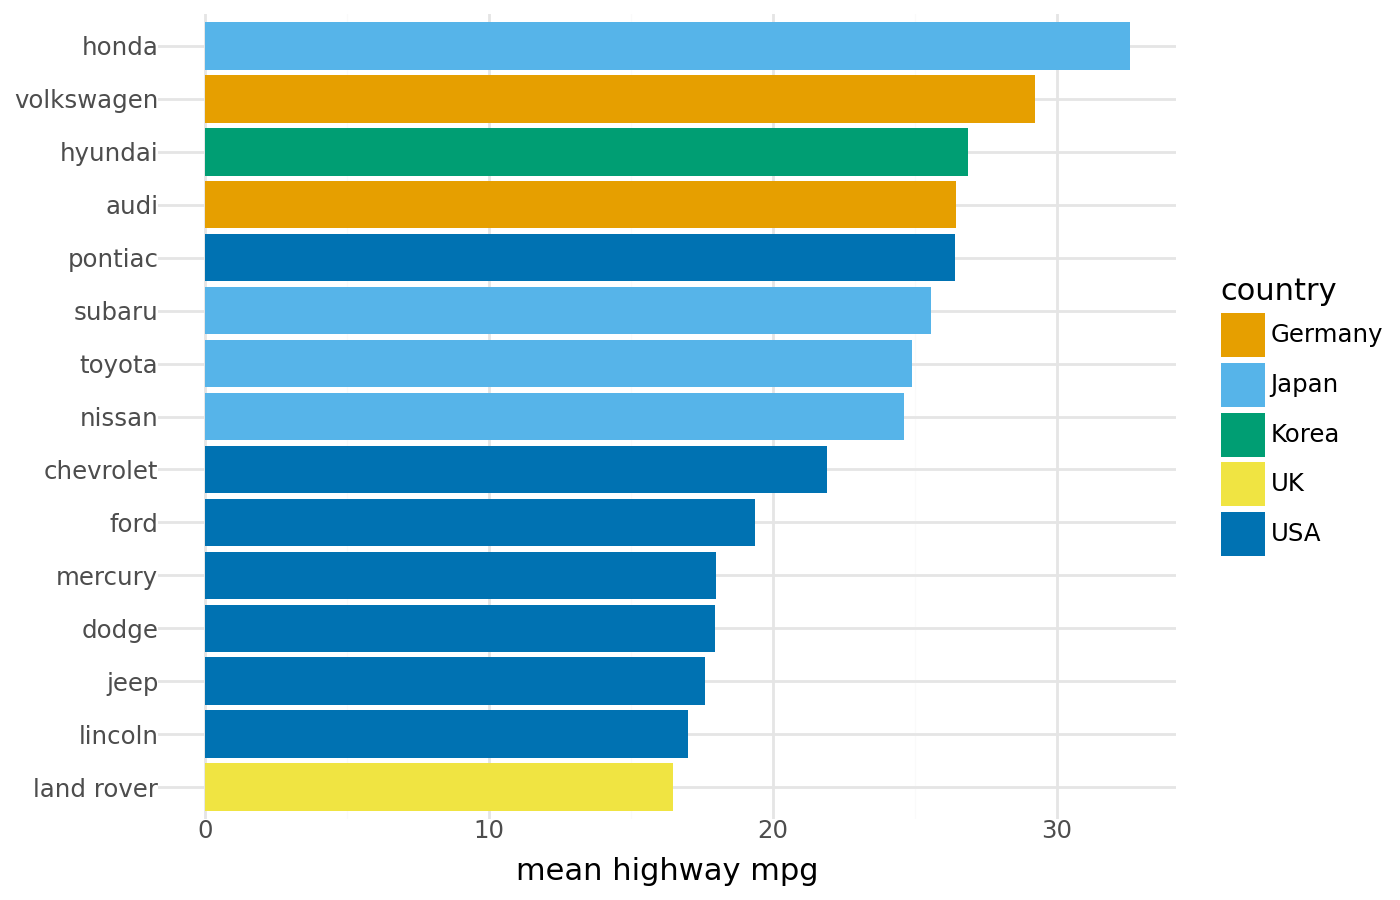

In [45]:
(
    ggplot(maker, aes(x="reorder(manufacturer, hwy)", y="hwy", fill="country"))    # TODO: 정렬된 제조사, 색상으로 구분할 변수
    + geom_col()
    + coord_flip()                                            # TODO: 막대를 가로로
    + scale_fill_manual(values=OKABE_ITO)                  # TODO: 정성적 팔레트
    + labs(x="", y="mean highway mpg", fill="country")
)

### 문제 3-2 (빈칸) — 강조 스케일
이번에는 **한국 제조사(hyundai)만 강조**하려고 합니다. 슬라이드 27처럼 나머지는 평이한 회색으로 두고, hyundai만 강렬한 색으로 칠하세요.

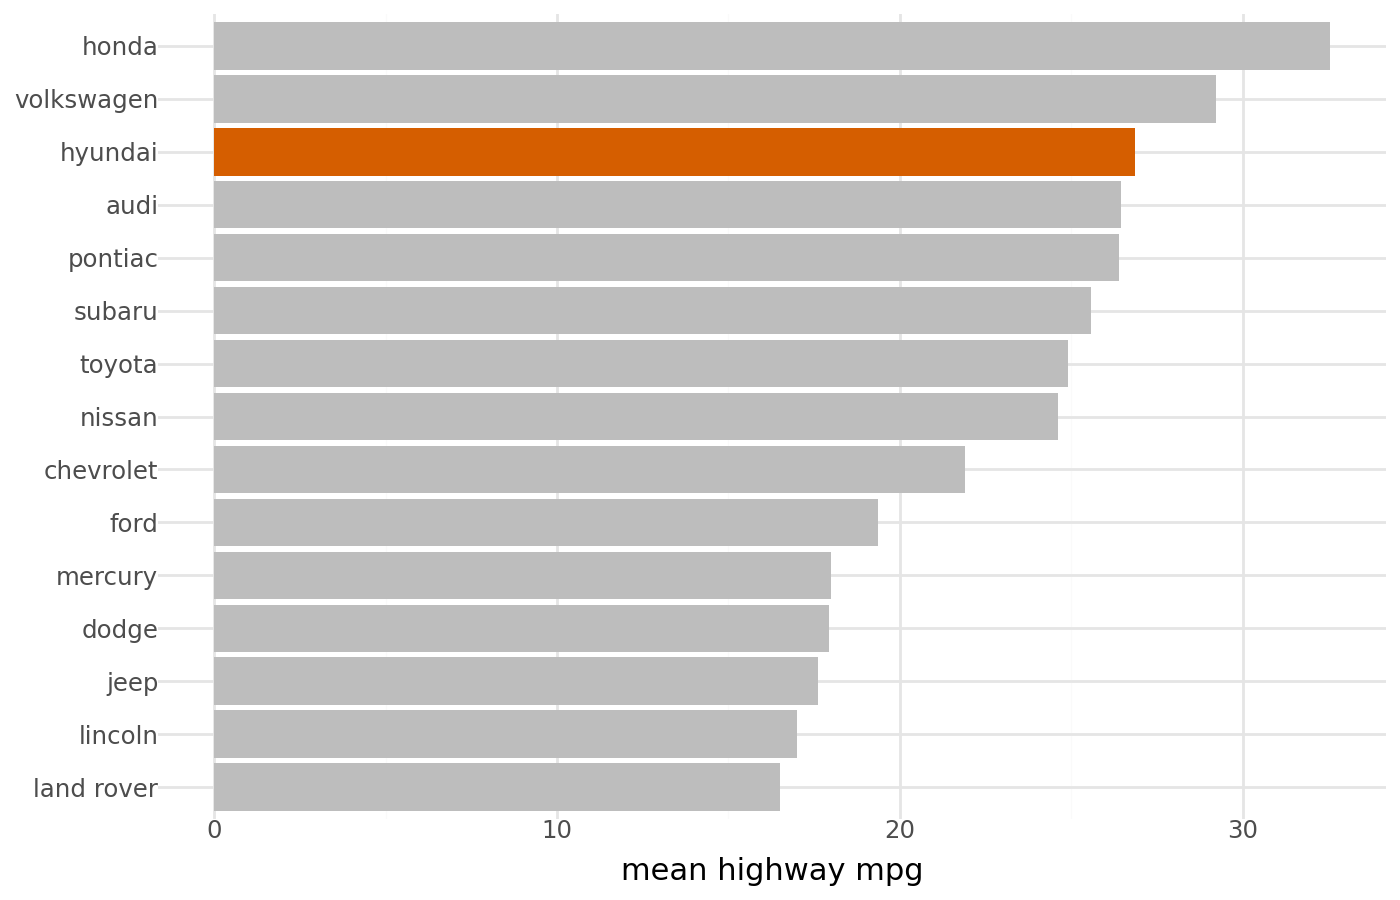

In [46]:
maker["highlight"] = np.where(maker["manufacturer"] == "hyundai", "hyundai", "other")   # TODO

(
    ggplot(maker, aes(x="reorder(manufacturer, hwy)", y="hwy", fill="highlight"))
    + geom_col()
    + coord_flip()
    + scale_fill_manual(values={"hyundai": "#D55E00", "other": "#BDBDBD"}, guide=None)        # TODO: 강조색 / 기본색
    + labs(x="", y="mean highway mpg")
)

### 문제 3-3 (빈칸) — 순차적 스케일 히트맵
슬라이드 39~40의 인터넷 사용자 히트맵처럼, 텍사스 46개 도시의 **연도별 주택 가격 중위값**을 히트맵으로 그립니다.
- 도시 순서는 **중위값이 처음으로 $150,000을 넘긴 연도** 기준입니다. 슬라이드 40과 같은 방식이에요.
- 값의 크기를 표현하므로 **순차적** 컬러맵 `magma`를 사용하세요.

In [47]:
tx = (
    txhousing.dropna(subset=["median"])
    .query("year <= 2014")
    .groupby(["city", "year"], as_index=False, observed=True)["median"].mean()
)

# 처음으로 $150,000을 넘긴 연도 (끝까지 못 넘기면 2100) → 빨리 넘긴 도시가 위로 오도록 정렬
first_year = (
    tx[tx["median"] >= 150_000].groupby("city", observed=True)["year"].min()
    .reindex(tx["city"].unique()).fillna(2100)
)
last_value = tx[tx["year"] == 2014].set_index("city")["median"].reindex(first_year.index)
order = (
    pd.DataFrame({"first": first_year, "last": last_value})
    .sort_values(["first", "last"], ascending=[False, True]).index
)
tx["city"] = pd.Categorical(tx["city"], categories=order)

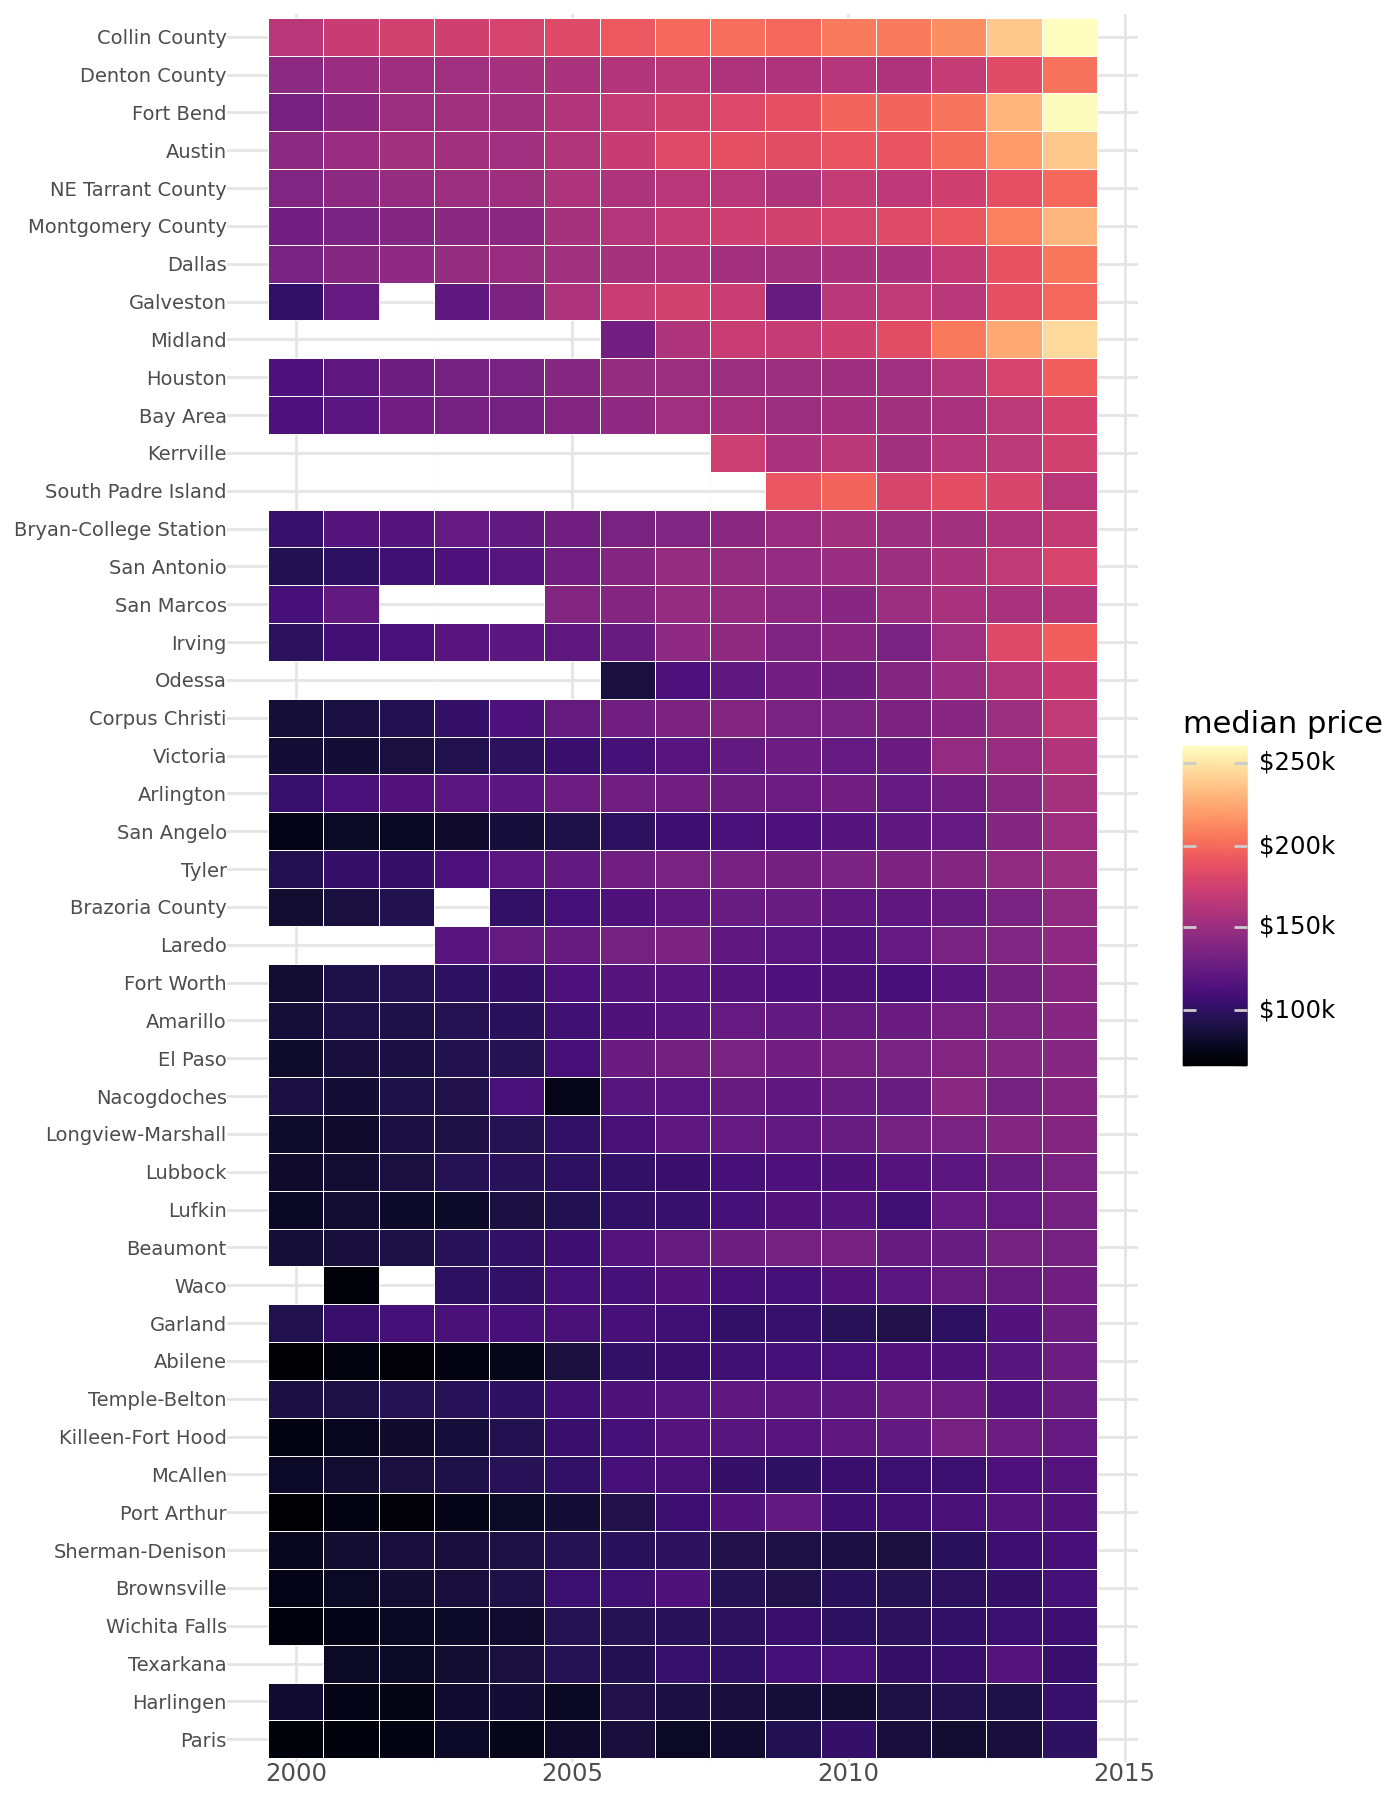

In [48]:
(
    ggplot(tx, aes(x="year", y="city", fill="median"))       # TODO: 색으로 표현할 값
    + geom_tile(color="white", size=0.2)                       # TODO: 히트맵을 그리는 geom
    + scale_fill_cmap("magma", labels=lambda v: [f"${x/1000:.0f}k" for x in v])   # TODO: 순차적 컬러맵
    + labs(x="", y="", fill="median price")
    + theme(figure_size=(7, 9), axis_text_y=element_text(size=7))
)

### 문제 3-4 (빈칸) — 발산형 스케일
이번에는 각 도시의 **연도별 월평균 주택 거래량(sales)이 그 도시의 전체 평균보다 몇 % 많거나 적은지** 표현합니다.
값에 **양수와 음수가 섞여 있고 0이 기준점**이므로, 0을 중립색(흰색)에 맞춘 발산형 스케일을 사용하세요.

In [49]:
sales = (
    txhousing.dropna(subset=["sales"])
    .query("year <= 2014")
    .groupby(["city", "year"], as_index=False, observed=True)["sales"].mean()   # 월평균 (기록이 일부 달만 있는 해도 공정하게 비교)
)
sales["pct_diff"] = sales.groupby("city")["sales"].transform(lambda s: (s / s.mean() - 1) * 100)
sales["city"] = pd.Categorical(sales["city"], categories=order)   # 3-3과 같은 도시 순서

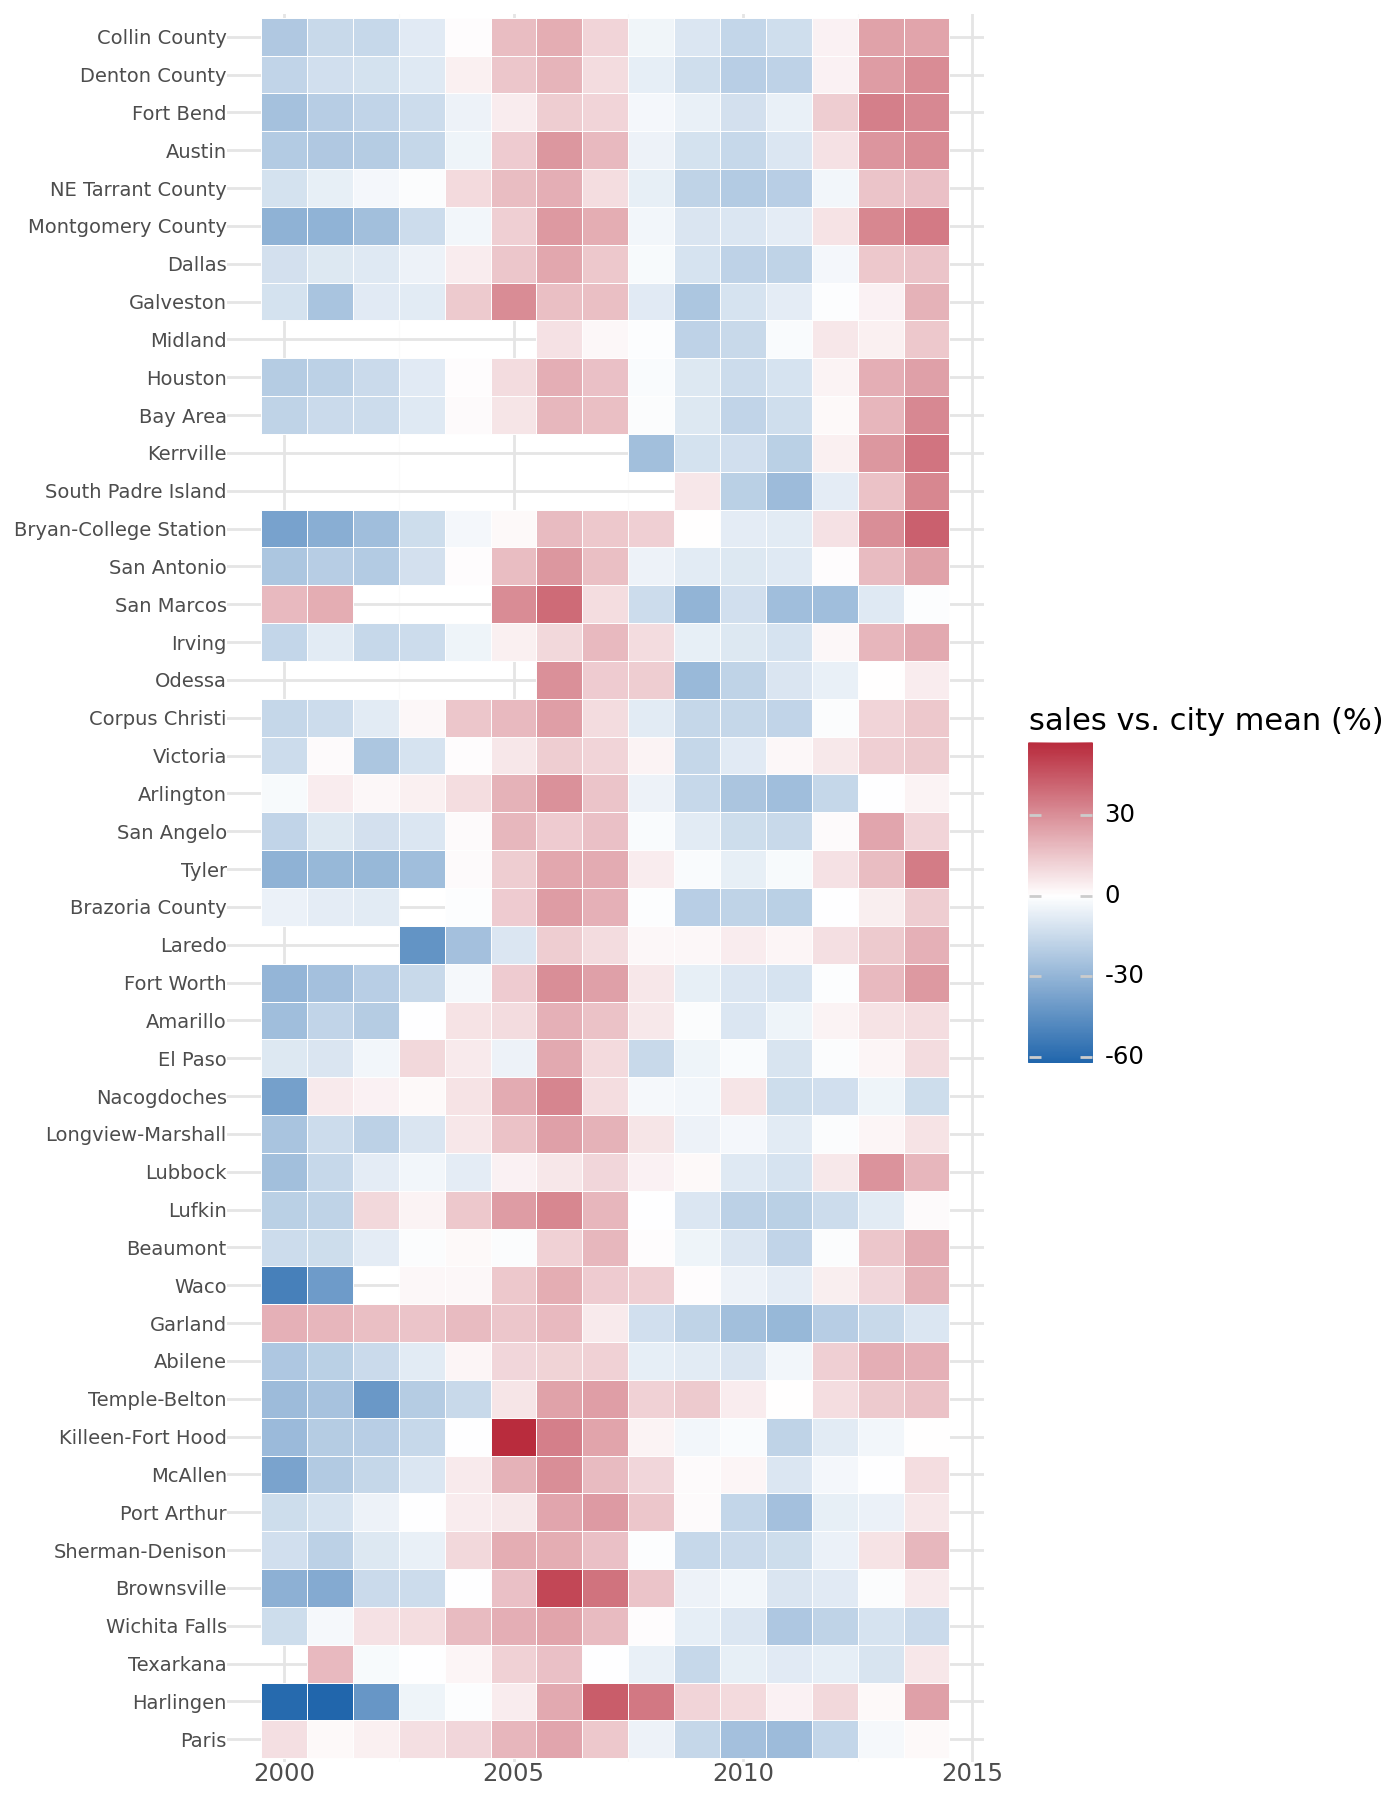

In [50]:
(
    ggplot(sales, aes(x="year", y="city", fill="pct_diff"))
    + geom_tile(color="white", size=0.2)
    + scale_fill_gradient2(low="#2166AC", mid="white", high="#B2182B", midpoint=0)   # TODO
    + labs(x="", y="", fill="sales vs. city mean (%)")
    + theme(figure_size=(7, 9), axis_text_y=element_text(size=7))
)

### 문제 3-5 📝
1. 3-3에는 순차적 스케일을, 3-4에는 발산형 스케일을 쓴 이유를 설명하세요.
2. 3-4 히트맵에서 텍사스 주택 시장에 대해 읽어낼 수 있는 패턴 하나를 적어 보세요.

**✍️ 답:**1번. 3-3에서는 주택 가격의 크기를 나타내기 때문에 값이 커질수록 색이 변하는 순차적 스케일을 사용했다. 반면 3-4에서는 도시별 평균 거래량과의 차이를 나타내므로 0을 기준으로 구분할 수 있는 발산형 스케일을 사용했다.
2번. 도시별 주택 거래량은 연도에 따라 변화하며, 같은 도시에서도 평균보다 거래량이 많은 시기와 적은 시기가 나타난다. 이를 통해 도시별 주택 시장의 변동을 비교할 수 있다.

## 4. 수량 데이터의 시각화

### 문제 4-1 🔧 고치기 — 막대도표
아래는 2014년 주택 거래량 상위 12개 도시를 그린 그래프입니다. 슬라이드 30에서 *조악함*으로 지적한 문제가 있습니다.
**정렬된 가로 막대 그래프**로 고치세요.

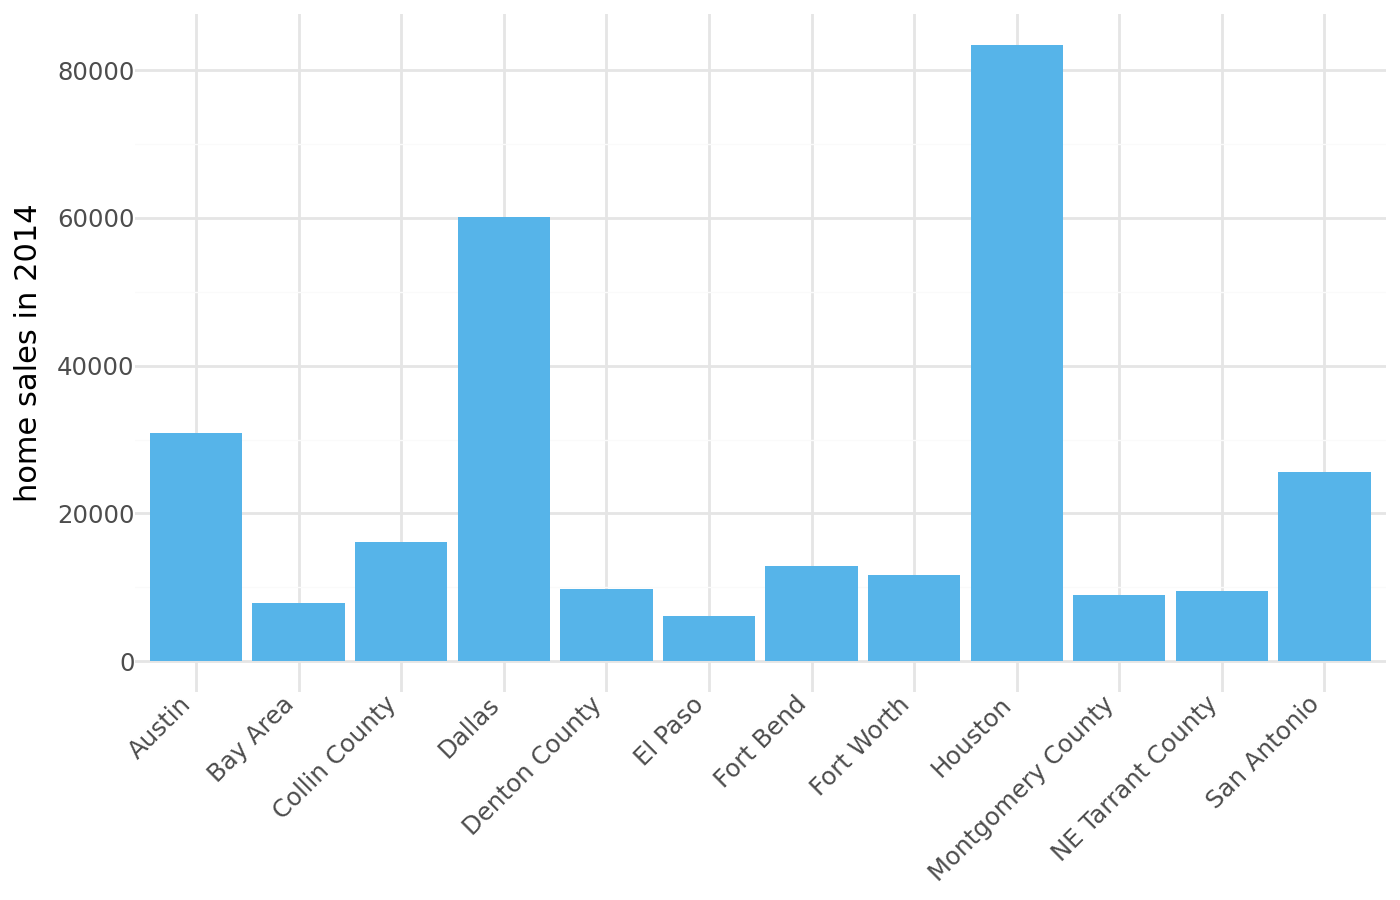

In [51]:
top12 = (
    txhousing.query("year == 2014").groupby("city", as_index=False)["sales"].sum()
    .nlargest(12, "sales")
    .sample(frac=1, random_state=7)   # 일부러 순서를 섞음
)

# ❌ 조악한 그래프 (그대로 두세요)
(
    ggplot(top12, aes(x="city", y="sales"))
    + geom_col(fill="#56B4E9")
    + theme(axis_text_x=element_text(rotation=45, ha="right"))
    + labs(x="", y="home sales in 2014")
)

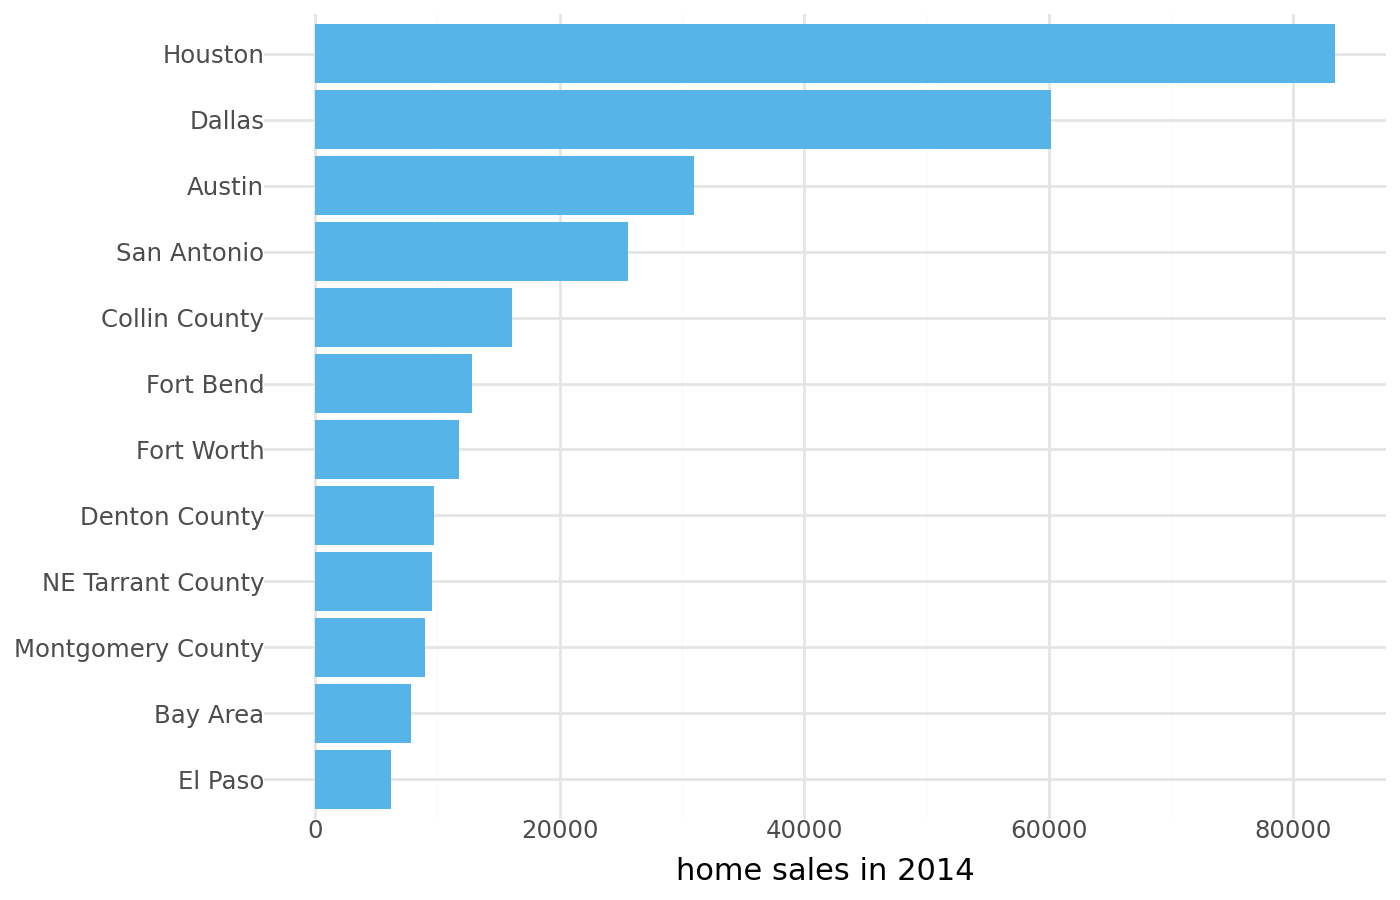

In [52]:
# ✅ 고친 그래프를 작성하세요

(
    ggplot(top12, aes(
        x="reorder(city, sales)",
        y="sales"
    ))
    + geom_col(fill="#56B4E9")
    + coord_flip()
    + labs(x="", y="home sales in 2014")
)


### 문제 4-2 🔧 고치기 — 순서가 있는 범주
아래는 휴스턴의 **월별 평균 주택 거래량**입니다. 4-1과 똑같이 값 순서로 정렬했는데, 슬라이드 32에 따르면 이번에는 오히려 *모호한* 그래프가 됩니다.
올바른 순서로 고치세요.

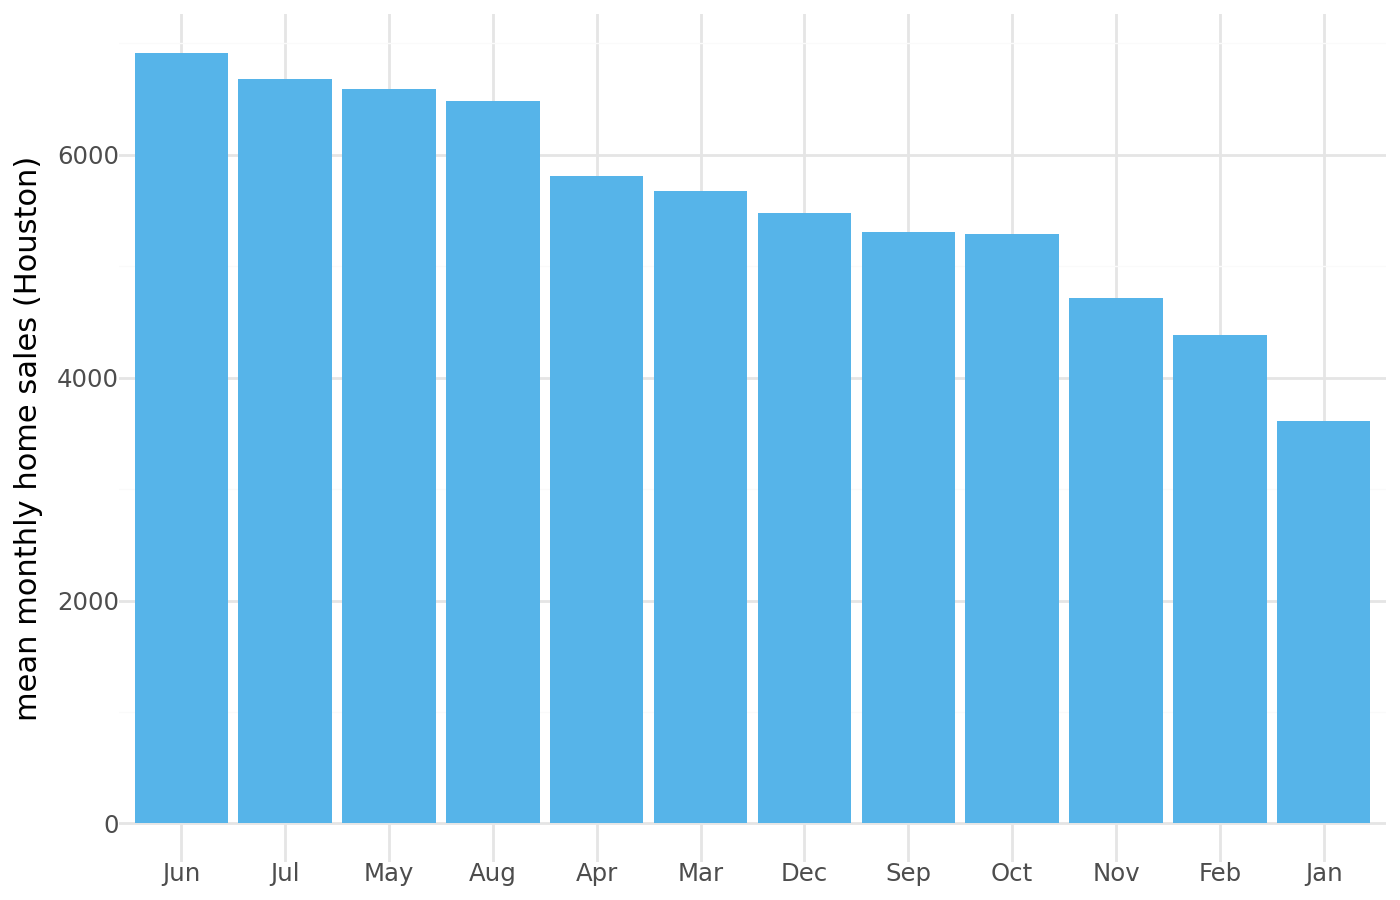

In [53]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

houston = txhousing.query("city == 'Houston'").groupby("month", as_index=False)["sales"].mean()
houston["month_name"] = [MONTHS[m - 1] for m in houston["month"]]

# ❌ 모호한 그래프 (그대로 두세요)
(
    ggplot(houston, aes(x="reorder(month_name, -sales)", y="sales"))
    + geom_col(fill="#56B4E9")
    + labs(x="", y="mean monthly home sales (Houston)")
)

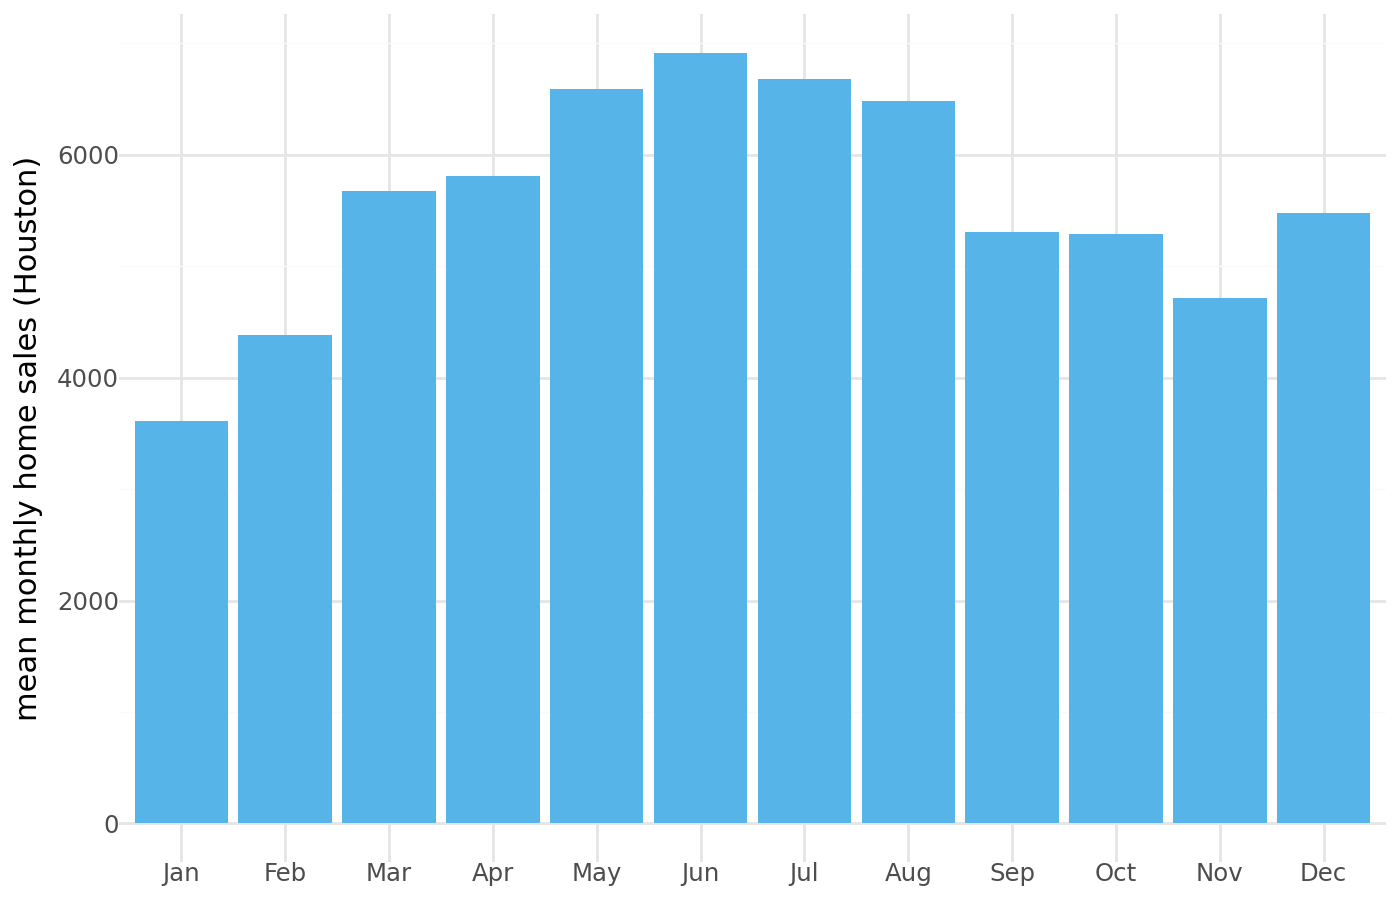

In [54]:
# ✅ 고친 그래프를 작성하세요 (힌트: pd.Categorical(..., categories=MONTHS, ordered=True))

houston["month_name"] = pd.Categorical(
    houston["month_name"],
    categories=MONTHS,
    ordered=True
)

(
    ggplot(houston, aes(x="month_name", y="sales"))
    + geom_col(fill="#56B4E9")
    + labs(x="", y="mean monthly home sales (Houston)")
)


### 문제 4-3 (빈칸) — 묶은 막대 vs 누적 막대
슬라이드 36의 **타이타닉 객실 등급별 승객 수**입니다. 같은 데이터를 두 가지 방법으로 그려 보세요.

In [55]:
titanic = pd.DataFrame({
    "pclass": ["1st", "1st", "2nd", "2nd", "3rd", "3rd"],
    "sex":    ["female", "male"] * 3,
    "count":  [143, 179, 107, 172, 212, 499],
})
titanic

,pclass,sex,count
0,1st,female,143
1,1st,male,179
2,2nd,female,107
3,2nd,male,172
4,3rd,female,212
5,3rd,male,499


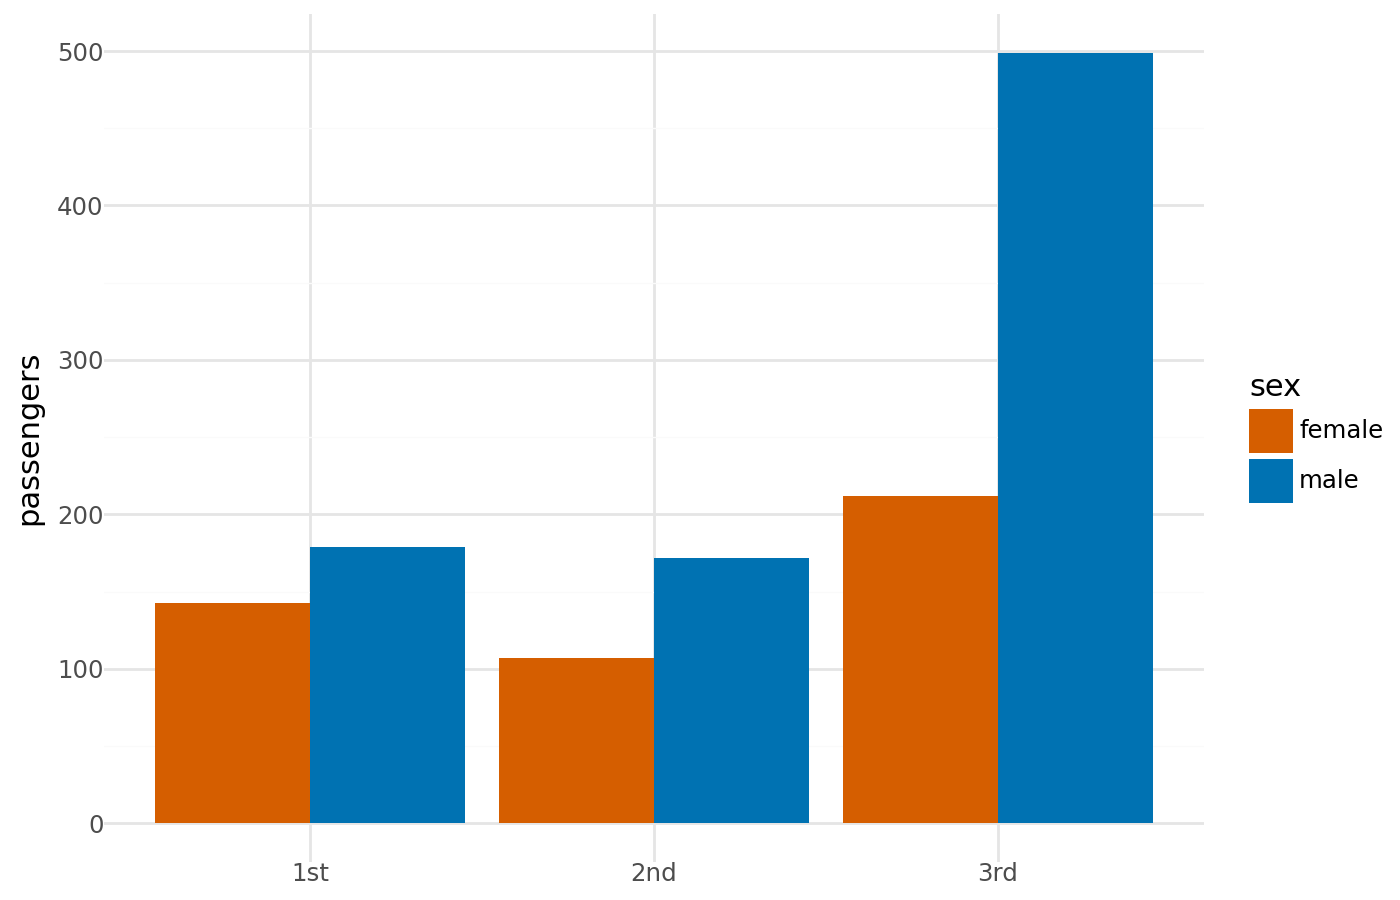

In [56]:
# (a) 묶은 막대: 성별을 나란히
(
    ggplot(titanic, aes(x="pclass", y="count", fill="sex"))
    + geom_col(position="dodge")                          # TODO
    + scale_fill_manual(values=["#D55E00", "#0072B2"])
    + labs(x="", y="passengers")
)

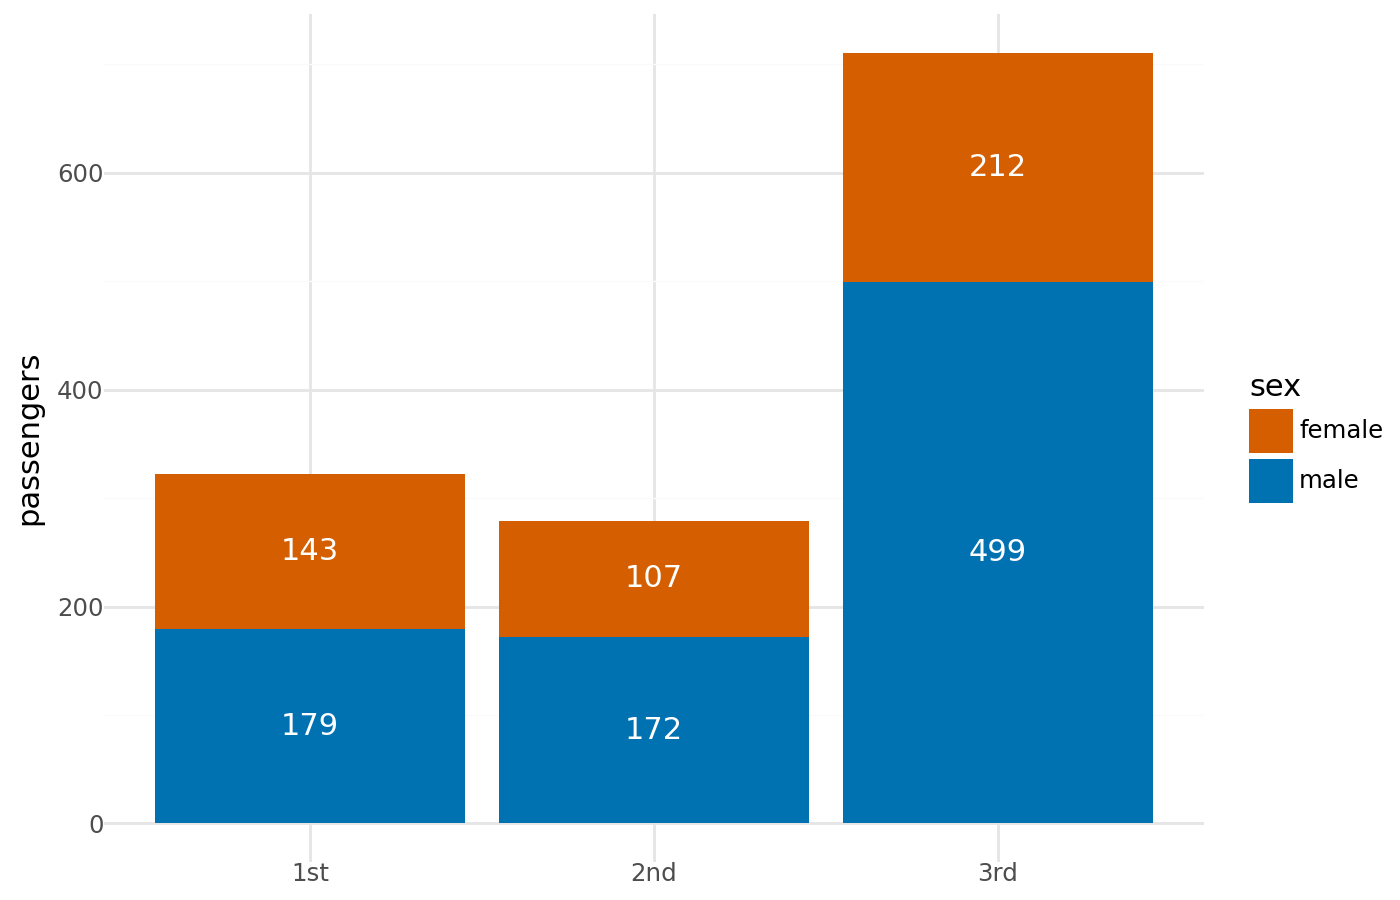

In [57]:
# (b) 누적 막대: 성별을 위로 쌓기 + 막대 안에 숫자 표시
(
    ggplot(titanic, aes(x="pclass", y="count", fill="sex"))
    + geom_col(position="stack")                          # TODO
    + geom_text(aes(label="count"), position=position_stack(vjust=0.5), color="white")
    + scale_fill_manual(values=["#D55E00", "#0072B2"])
    + labs(x="", y="passengers")
)

### 문제 4-4 📝
(a)와 (b) 중 **"3등실에 탄 승객이 전체적으로 가장 많다"** 는 사실을 보여주기에 더 좋은 그래프는 무엇이고, 그 이유는 무엇인가요?
반대로 **"각 등급에서 남성이 여성보다 몇 명 더 많은가"** 를 비교하기에는 어느 쪽이 나은가요?

**✍️ 답:**(b) 누적 막대 그래프가 더 적합하다. 남성과 여성의 승객 수를 합친 전체 높이를 비교할 수 있기 때문에 객실 등급별 총승객 수의 차이를 쉽게 확인할 수 있다. / (a) 묶은 막대 그래프가 더 적합하다. 남성과 여성의 막대가 나란히 배치되어 있어 각 등급에서 성별에 따른 승객 수 차이를 쉽게 비교할 수 있기 때문이다.

### 문제 4-5 🔧 고치기 — 점 도표
2014년 텍사스 도시별 **주택 가격 중위값**을 막대로 그렸더니, 슬라이드 38처럼 막대 길이가 거의 비슷해 차이가 두드러지지 않습니다.
정렬된 **점 도표**로 고치세요.

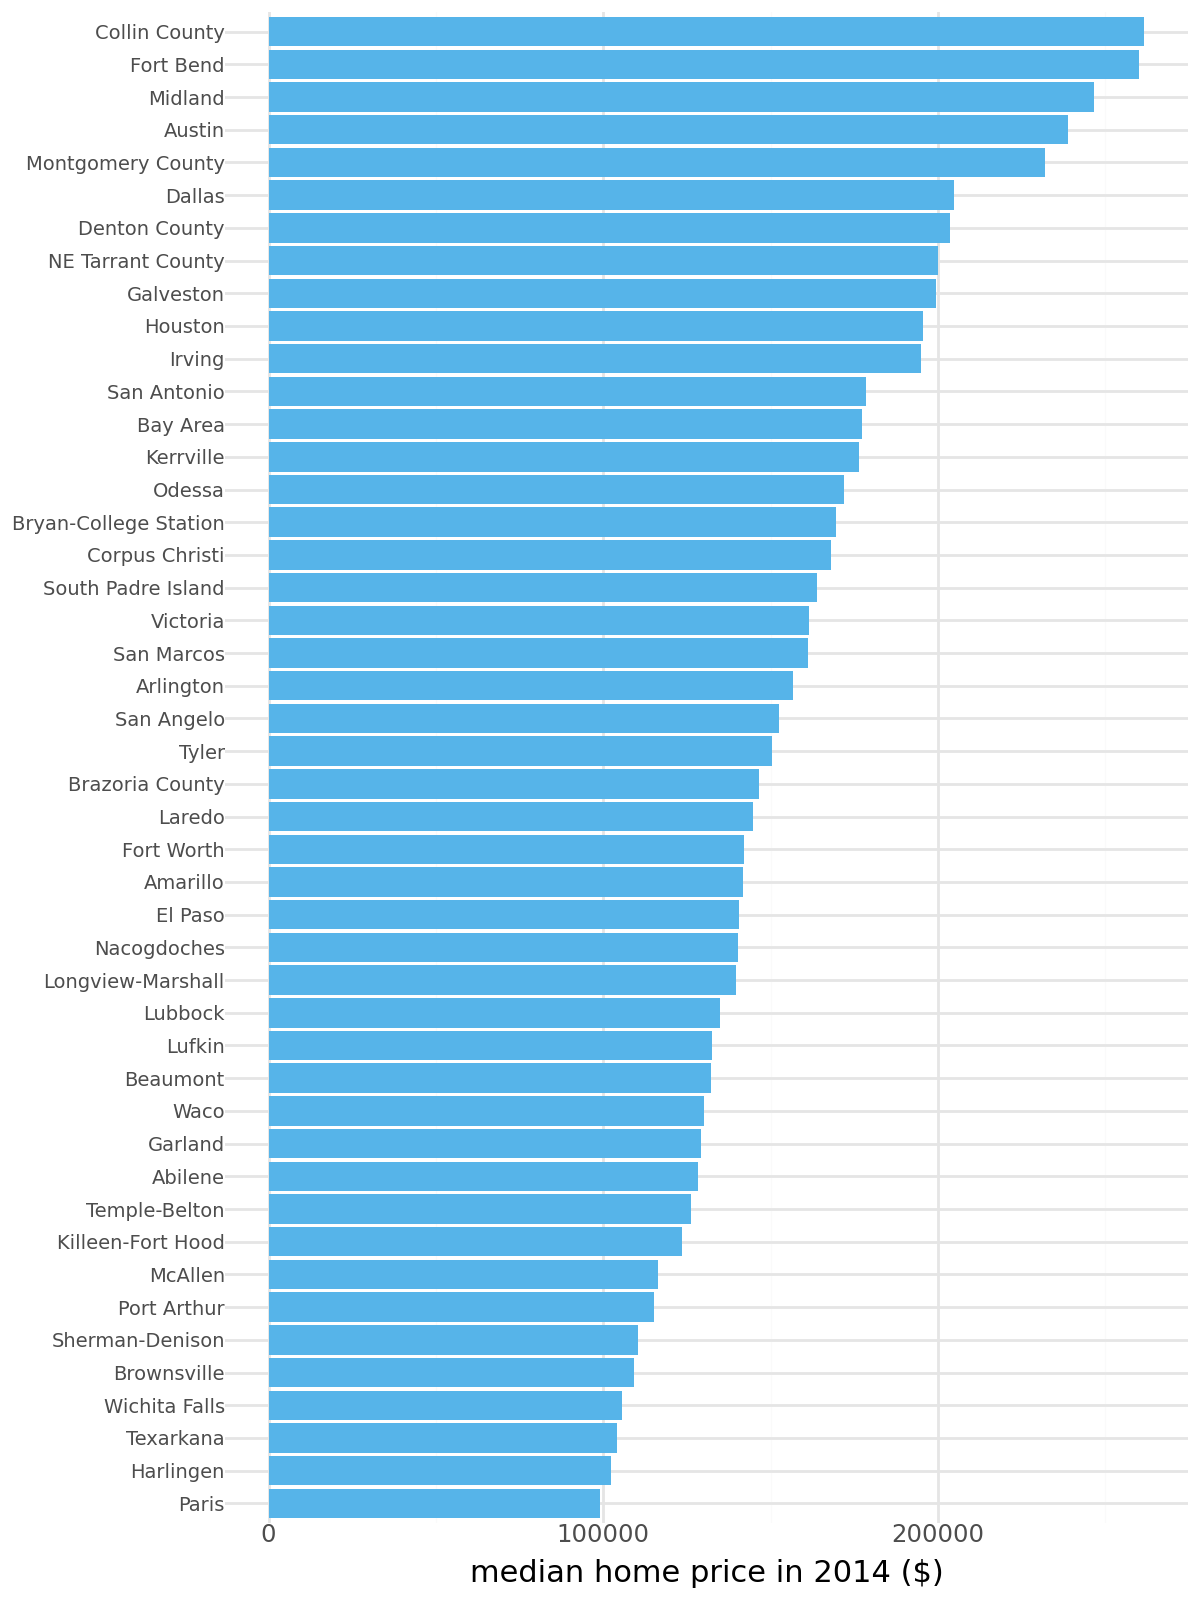

In [58]:
price14 = txhousing.query("year == 2014").groupby("city", as_index=False)["median"].mean().dropna()

# ❌ 모호한 그래프 (그대로 두세요)
(
    ggplot(price14, aes(x="reorder(city, median)", y="median"))
    + geom_col(fill="#56B4E9")
    + coord_flip()
    + labs(x="", y="median home price in 2014 ($)")
    + theme(figure_size=(6, 8), axis_text_y=element_text(size=7))
)

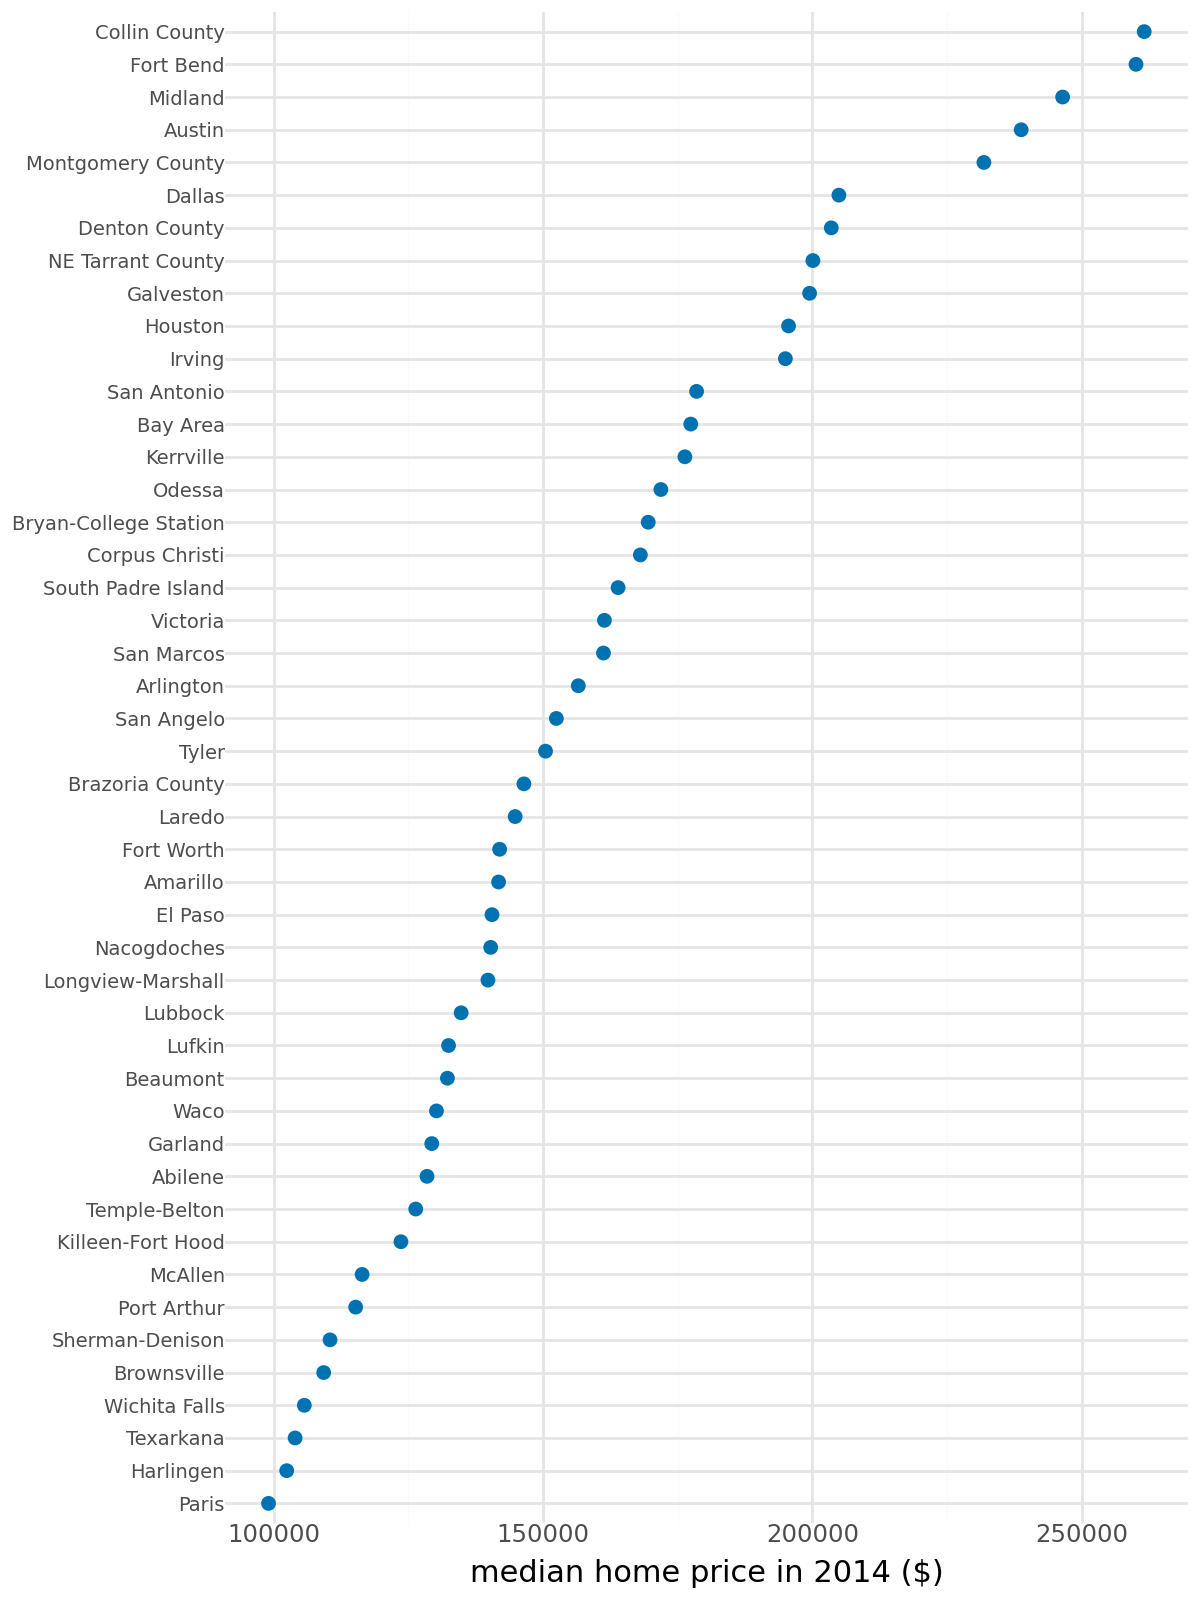

In [59]:
# ✅ 고친 그래프를 작성하세요

(
    ggplot(price14, aes(
        x="reorder(city, median)",
        y="median"
    ))
    + geom_point(color="#0072B2", size=2)
    + coord_flip()
    + labs(x="", y="median home price in 2014 ($)")
    + theme(
        figure_size=(6, 8),
        axis_text_y=element_text(size=7)
    )
)


### 문제 4-6 📝
막대도표에서는 **y축을 0이 아닌 곳에서 시작하면 안 되는데**, 점 도표에서는 괜찮은 이유는 무엇일까요?

**✍️ 답:**
막대도표는 막대의 길이로 값의 크기를 표현하므로 축이 0에서 시작하지 않으면 차이가 실제보다 과장될 수 있다. 반면 점 도표는 점의 위치를 통해 값을 비교하기 때문에 축을 반드시 0에서 시작할 필요가 없으며, 특정 구간을 확대해 작은 차이를 비교할 수 있다.

## 5. 분포 데이터의 시각화

`faithful`은 옐로스톤의 Old Faithful 간헐천 데이터이고, `waiting`은 분출 사이의 대기 시간(분)입니다.

### 문제 5-1 (빈칸) — 히스토그램의 구간 폭
구간 폭(`binwidth`)을 **1, 5, 10, 20분**으로 바꿔 가며 히스토그램 4개를 그리세요.

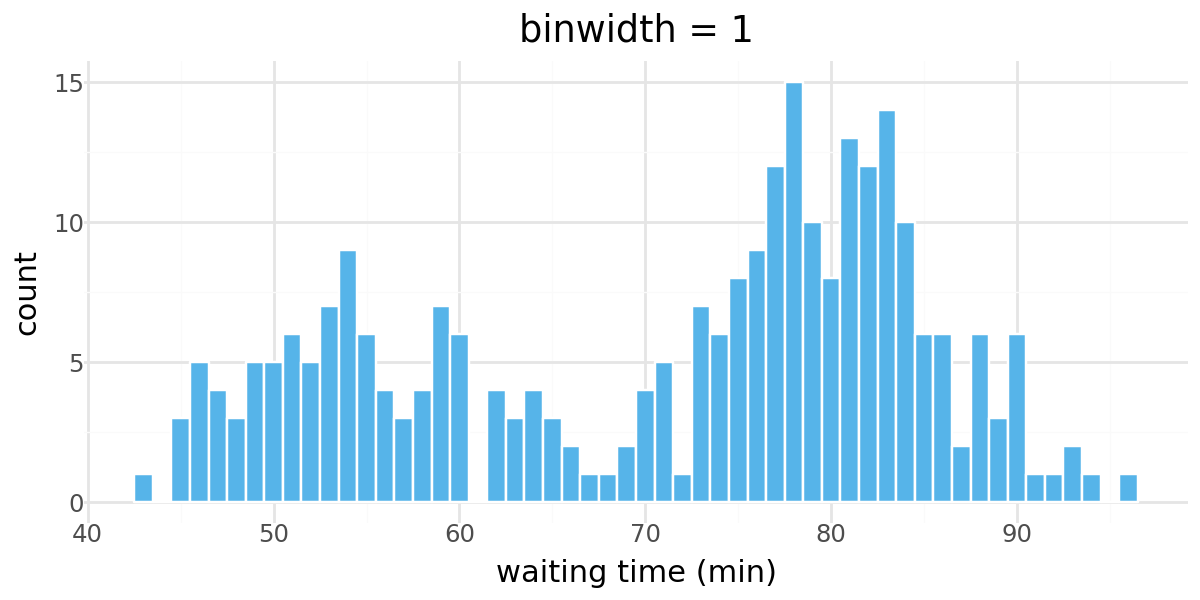

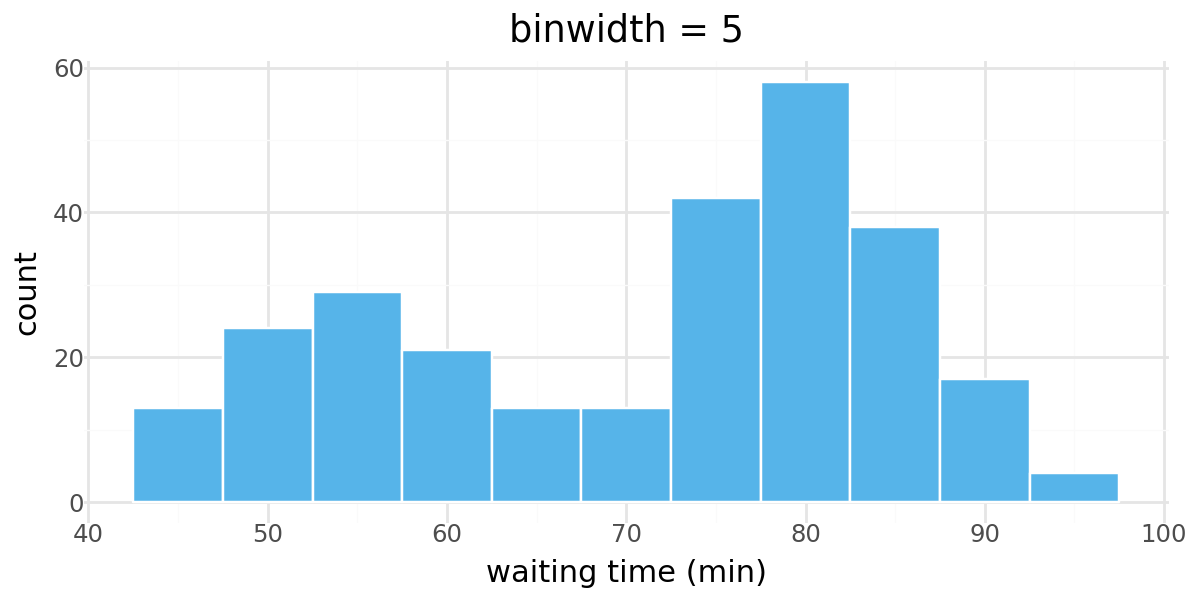

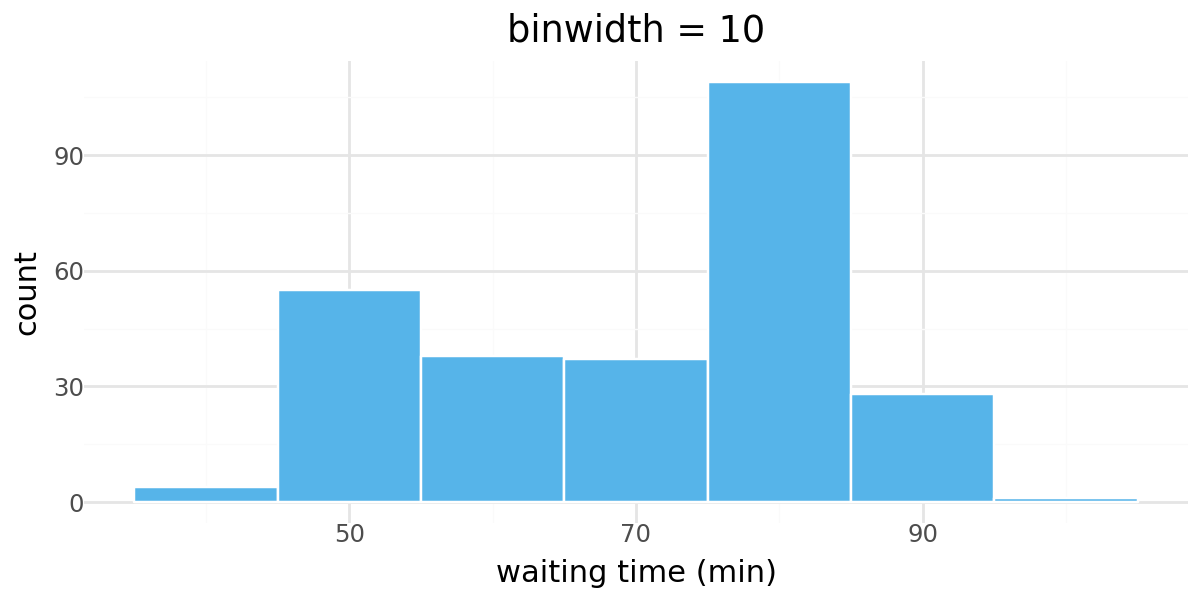

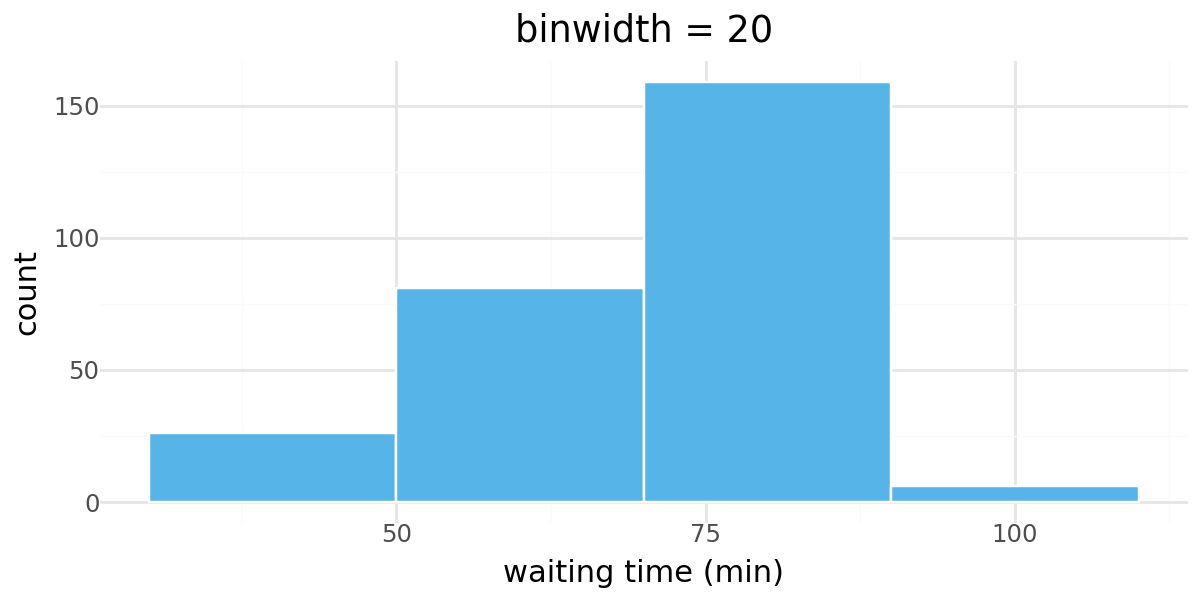

In [60]:
for bw in [1, 5, 10, 20]:
    display(
        ggplot(faithful, aes(x="waiting"))
        + geom_histogram(binwidth=bw, fill="#56B4E9", color="white")   # TODO
        + labs(title=f"binwidth = {bw}", x="waiting time (min)", y="count")
        + theme(figure_size=(6, 3))
    )

### 문제 5-2 (빈칸) — 밀도 도표의 대역폭
`geom_density`의 `adjust`는 기본 대역폭에 곱하는 배수입니다. `adjust`를 **0.2, 1, 3**으로 바꿔 가며 밀도 도표를 그리세요.

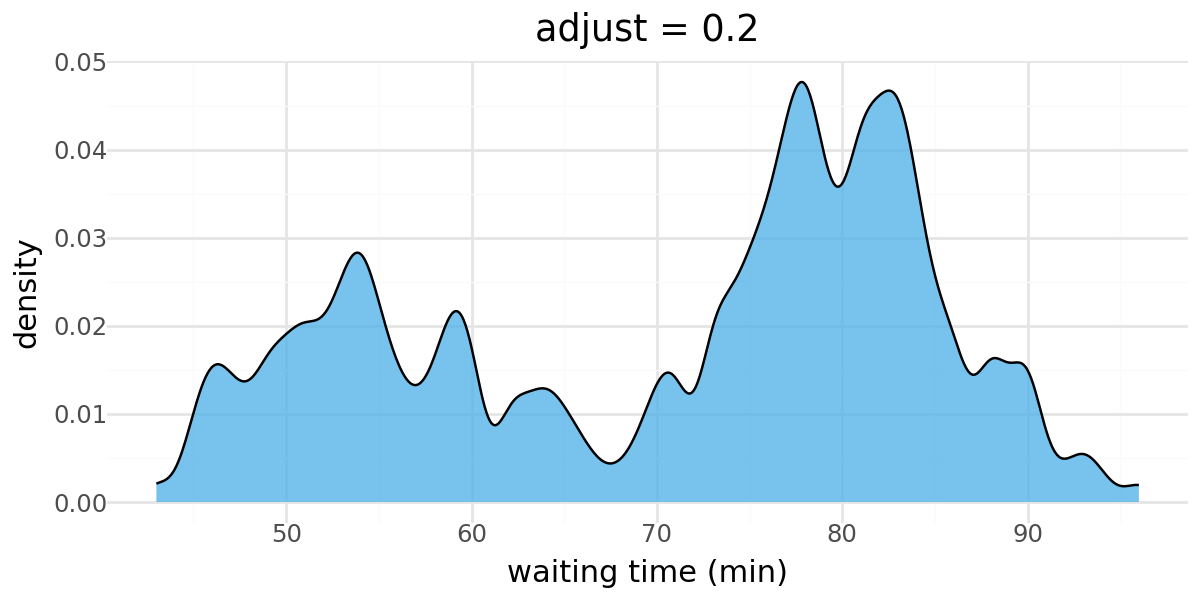

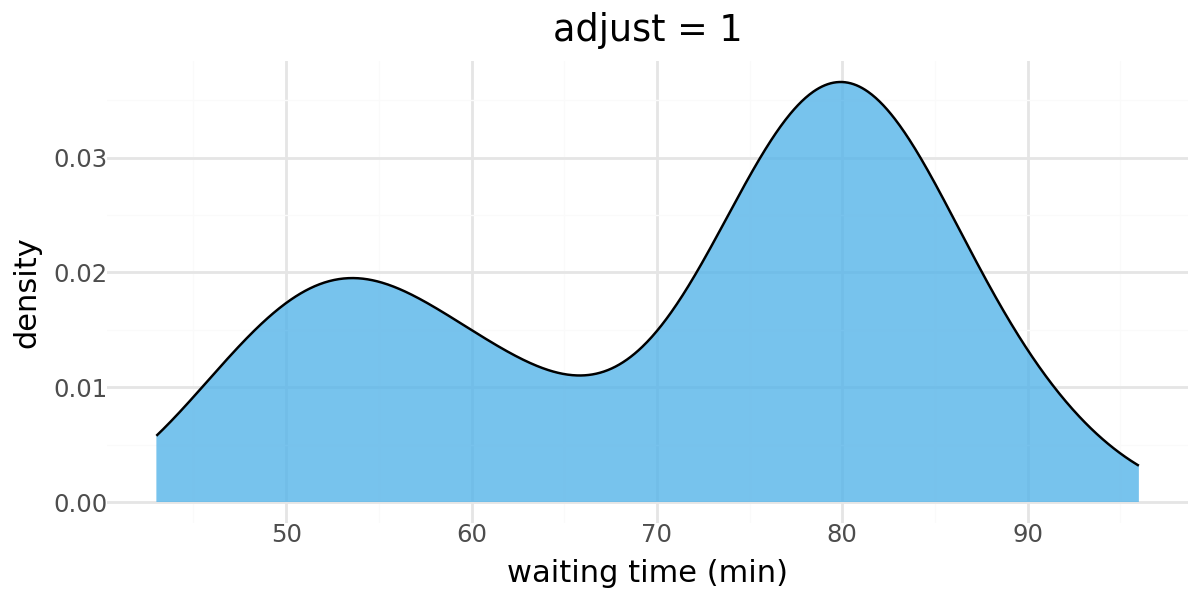

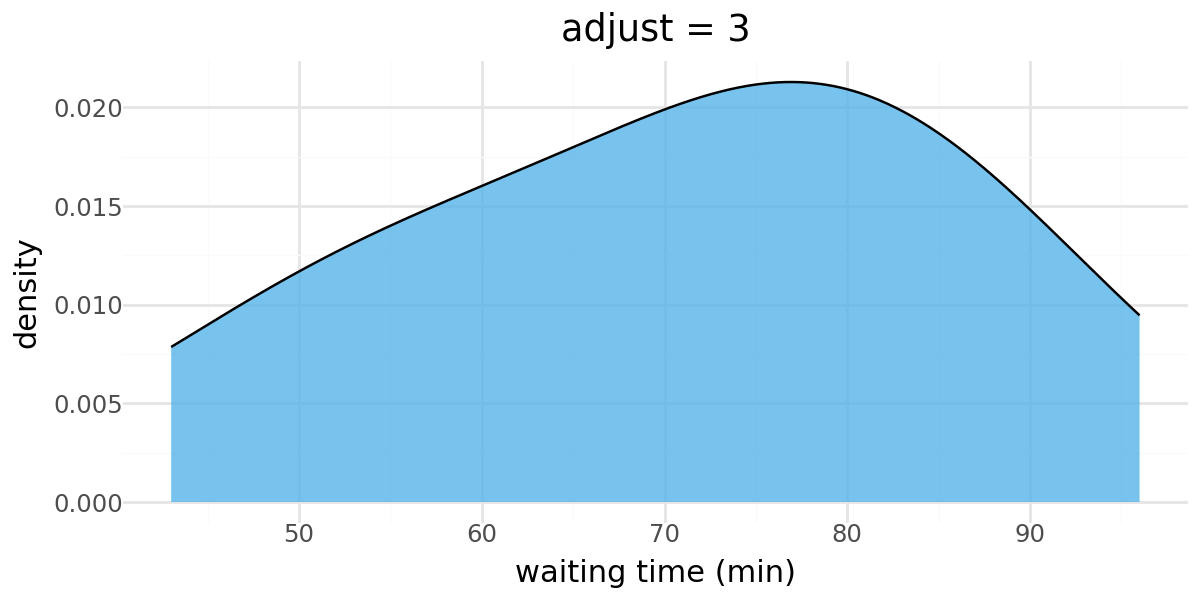

In [61]:
for adj in [0.2, 1, 3]:
    display(
        ggplot(faithful, aes(x="waiting"))
        + geom_density(adjust=adj, fill="#56B4E9", alpha=0.8)    # TODO: 밀도 도표 geom
        + labs(title=f"adjust = {adj}", x="waiting time (min)", y="density")
        + theme(figure_size=(6, 3))
    )

### 문제 5-3 📝
1. 5-1에서 구간 폭이 **너무 좁을 때**와 **너무 넓을 때** 각각 어떤 문제가 생기나요? 특히 binwidth = 20에서 사라지는 중요한 특징은 무엇인가요?
2. 5-2에서 대역폭을 크게 하면 그래프가 어떻게 변하나요? 데이터에 대해 어떤 오해를 할 수 있을까요?

**✍️ 답:** 1번. 구간 폭이 너무 좁으면 데이터의 작은 변동까지 나타나 전체적인 분포를 파악하기 어렵다. 반대로 구간 폭이 너무 넓으면 데이터의 세부적인 특징이 사라진다. 2번. 대역폭이 커지면 그래프의 곡선이 부드러워지는데 지나치게 크면 실제로 존재하는 여러 봉우리가 하나로 합쳐져 보일 수 있으므로 데이터의 분포를 잘못 해석할 수 있다.

### 문제 5-4 🔧 고치기 — 여러 분포 비교
펭귄 3종의 **몸무게 분포**를 비교하려고 누적 히스토그램을 그렸습니다. 슬라이드 46처럼 막대의 시작 위치가 제각각이라 각 종의 분포를 읽기 어렵습니다.
슬라이드 51처럼 **반투명한 중첩 밀도 도표**로 고치고, 범례 대신 곡선 옆에 **종 이름을 직접 표시**해 보세요.

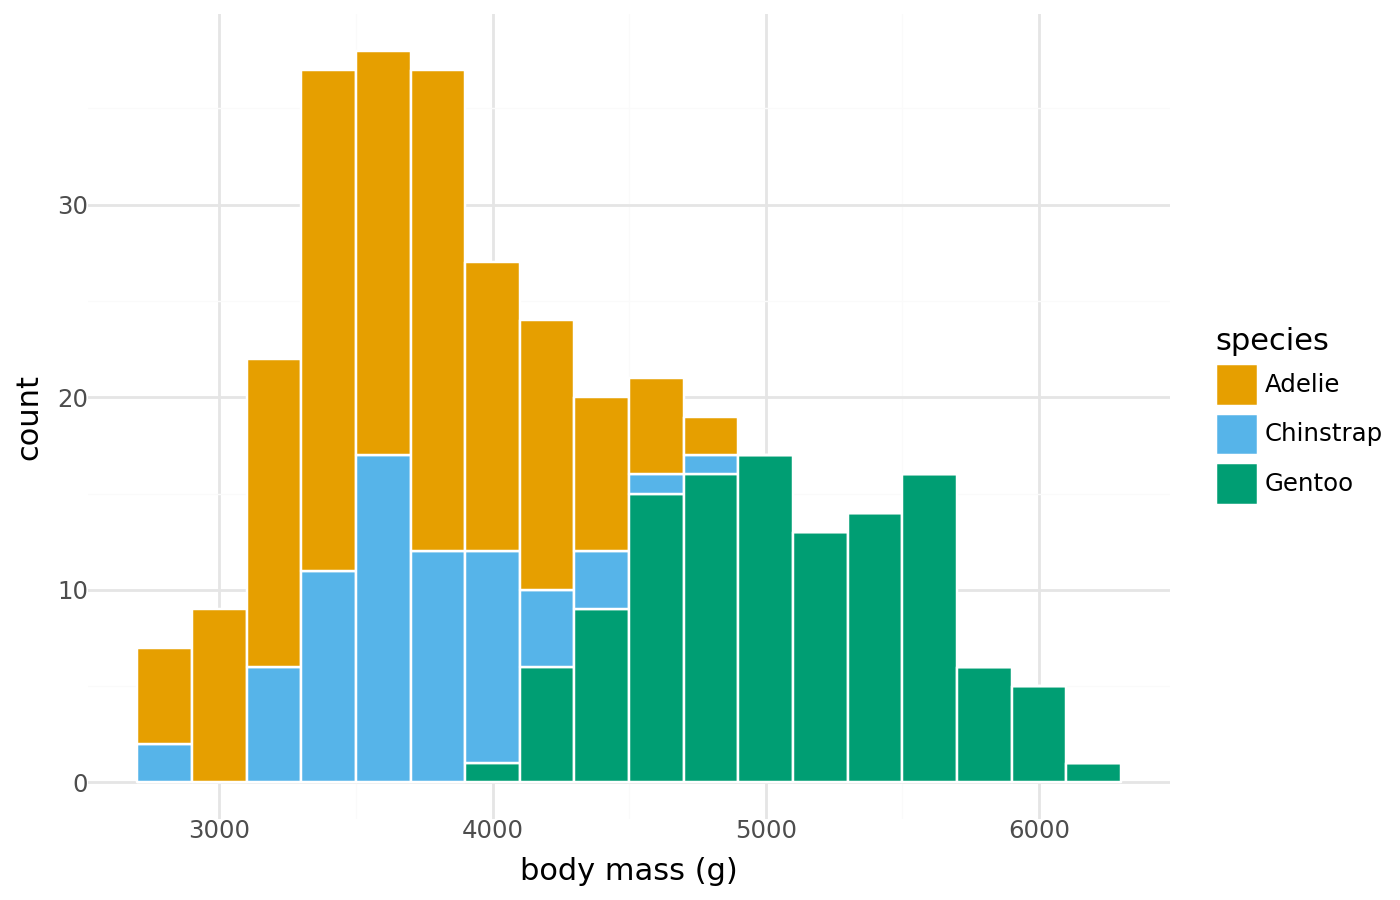

In [62]:
peng = penguins.dropna(subset=["body_mass_g", "sex"])

# ❌ 모호한 그래프 (그대로 두세요)
(
    ggplot(peng, aes(x="body_mass_g", fill="species"))
    + geom_histogram(binwidth=200, position="stack", color="white")
    + scale_fill_manual(values=OKABE_ITO)
    + labs(x="body mass (g)", y="count")
)

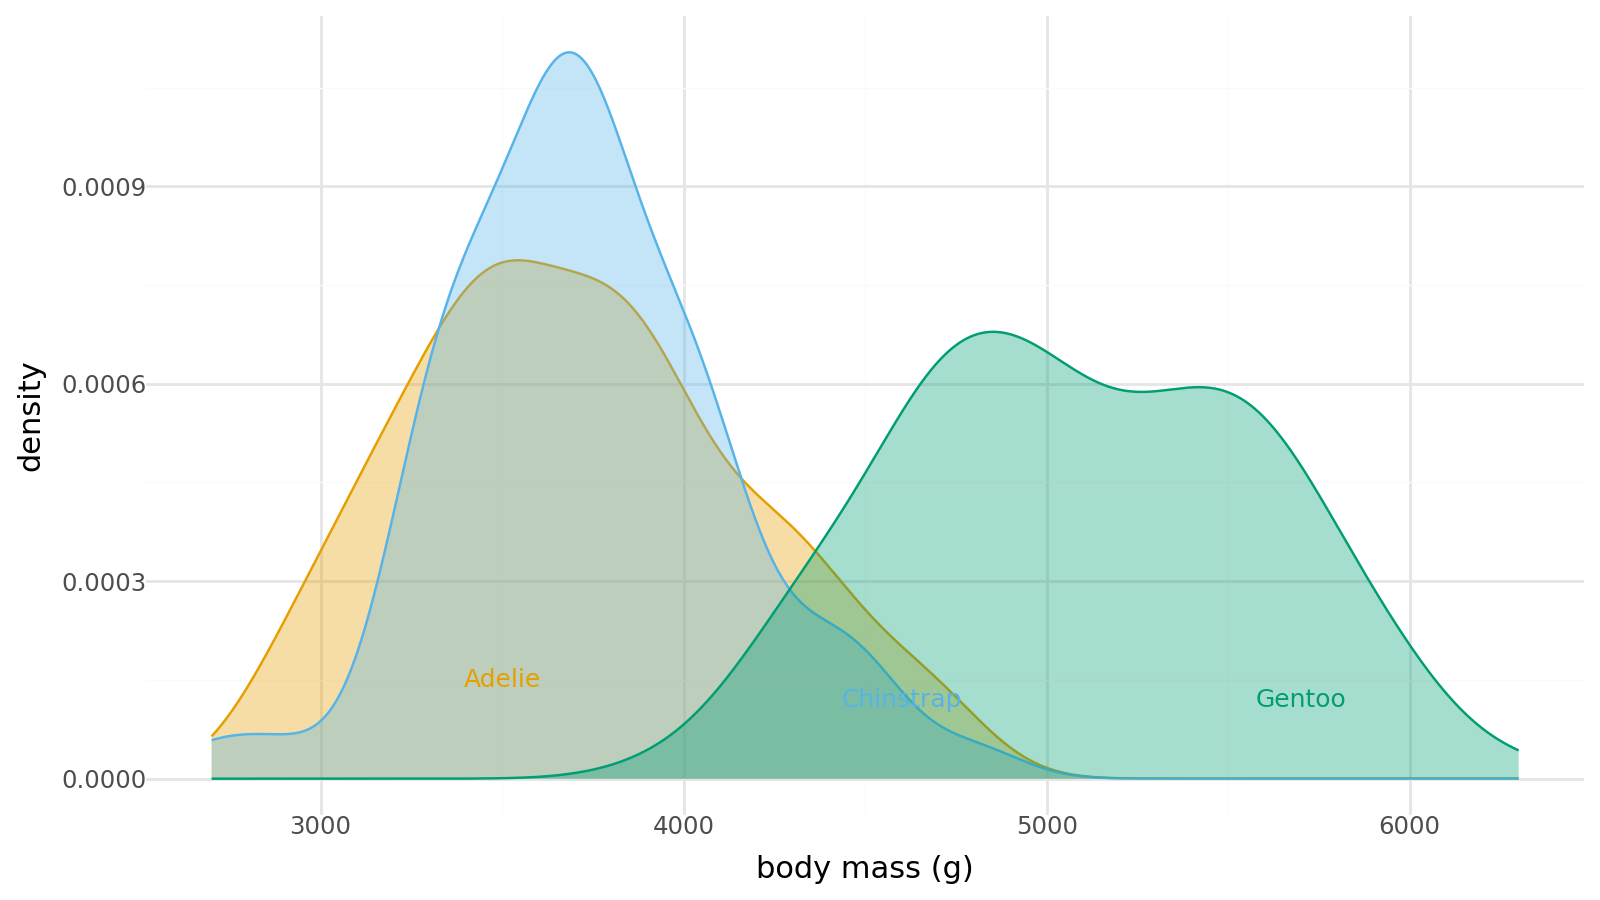

In [63]:
# ✅ 고친 그래프를 작성하세요
# 힌트: geom_density(alpha=...), 직접 라벨은 geom_text(..., data=라벨용 DataFrame)

# 잘못된 점: 누적 히스토그램은 각 종의 막대 시작 위치가 달라
# 펭귄 종별 몸무게 분포를 직접 비교하기 어렵다.
# 수정 방법: 반투명한 밀도 도표를 겹쳐 표현한다.
# 범례 대신 각 곡선 근처에 종 이름을 직접 표시한다.

species_colors = {
    "Adelie": "#E69F00",
    "Chinstrap": "#56B4E9",
    "Gentoo": "#009E73"
}

labels = pd.DataFrame({
    "species": ["Adelie", "Chinstrap", "Gentoo"],
    "body_mass_g": [3500, 4600, 5700],
    "density": [0.00015, 0.00012, 0.00012]
})

(
    ggplot(
        peng,
        aes(
            x="body_mass_g",
            fill="species",
            color="species"
        )
    )
    + geom_density(alpha=0.35)
    + geom_text(
        data=labels,
        mapping=aes(
            x="body_mass_g",
            y="density",
            label="species",
            color="species"
        ),
        inherit_aes=False,
        size=9
    )
    + scale_fill_manual(
        values=species_colors,
        guide=None
    )
    + scale_color_manual(
        values=species_colors,
        guide=None
    )
    + labs(
        x="body mass (g)",
        y="density"
    )
    + theme(figure_size=(8, 4.5))
)


### 문제 5-5 (빈칸) — 전체 분포 대비 비중
슬라이드 49처럼 **수컷과 암컷의 날개 길이 분포**를 따로 그리되, 각 패널 뒤에 **전체 펭귄의 분포를 회색으로** 깔아서 각 성별이 전체에서 차지하는 비중을 보여 주세요.

> 💡 **핵심 아이디어**: 회색 배경 레이어에 `sex` 열이 **없는** 데이터를 주면, `facet_wrap("sex")`이 그 레이어를 모든 패널에 똑같이 그립니다.
> y축은 `after_stat("count")`로 **밀도 × 개수**를 써서, 전체 곡선 아래 면적이 전체 마릿수가 되게 합니다.

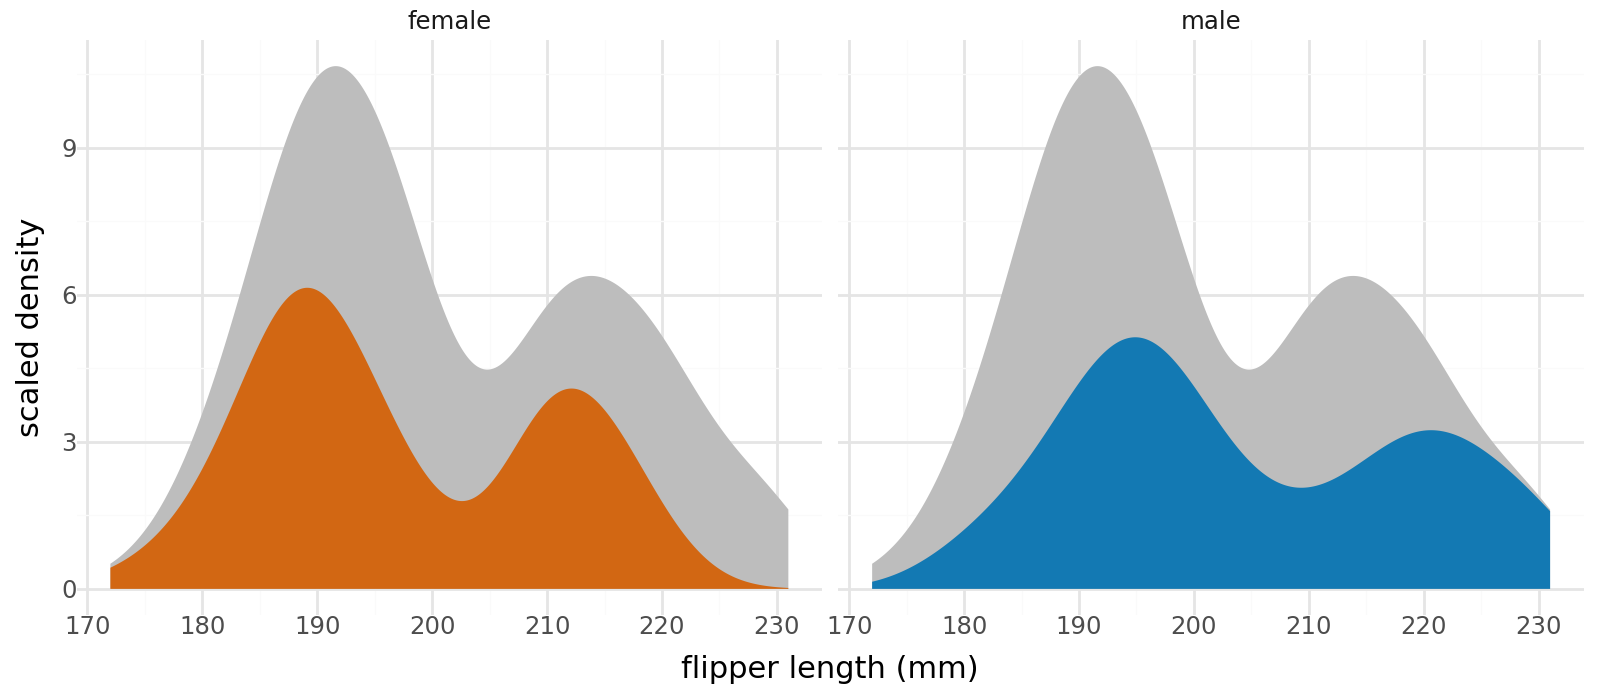

In [64]:
all_peng = peng.drop(columns=["sex"])    # TODO: 어떤 열을 없애야 할까요?

(
    ggplot(peng, aes(x="flipper_length_mm", y=after_stat("count")))
    + geom_density(data=all_peng, fill="#BDBDBD", color="none")        # TODO: 회색 배경 = 전체 데이터
    + geom_density(aes(fill="sex"), color="none", alpha=0.9)
    + facet_wrap("sex")                                                        # TODO: 성별로 패널 나누기
    + scale_fill_manual(values={"male": "#0072B2", "female": "#D55E00"}, guide=None)
    + labs(x="flipper length (mm)", y="scaled density")
    + theme(figure_size=(8, 3.5))
)

### 문제 5-6 (보너스) 연령 피라미드 스타일
슬라이드 50의 **연령 피라미드**처럼 수컷과 암컷의 **몸무게 히스토그램**을 좌우로 마주 보게 그려 보세요.

> 💡 힌트: 구간별 개수를 직접 세고(`pd.cut`), 한쪽 성별의 개수에 **−1을 곱한 뒤** `geom_col` + `coord_flip()`을 사용합니다.

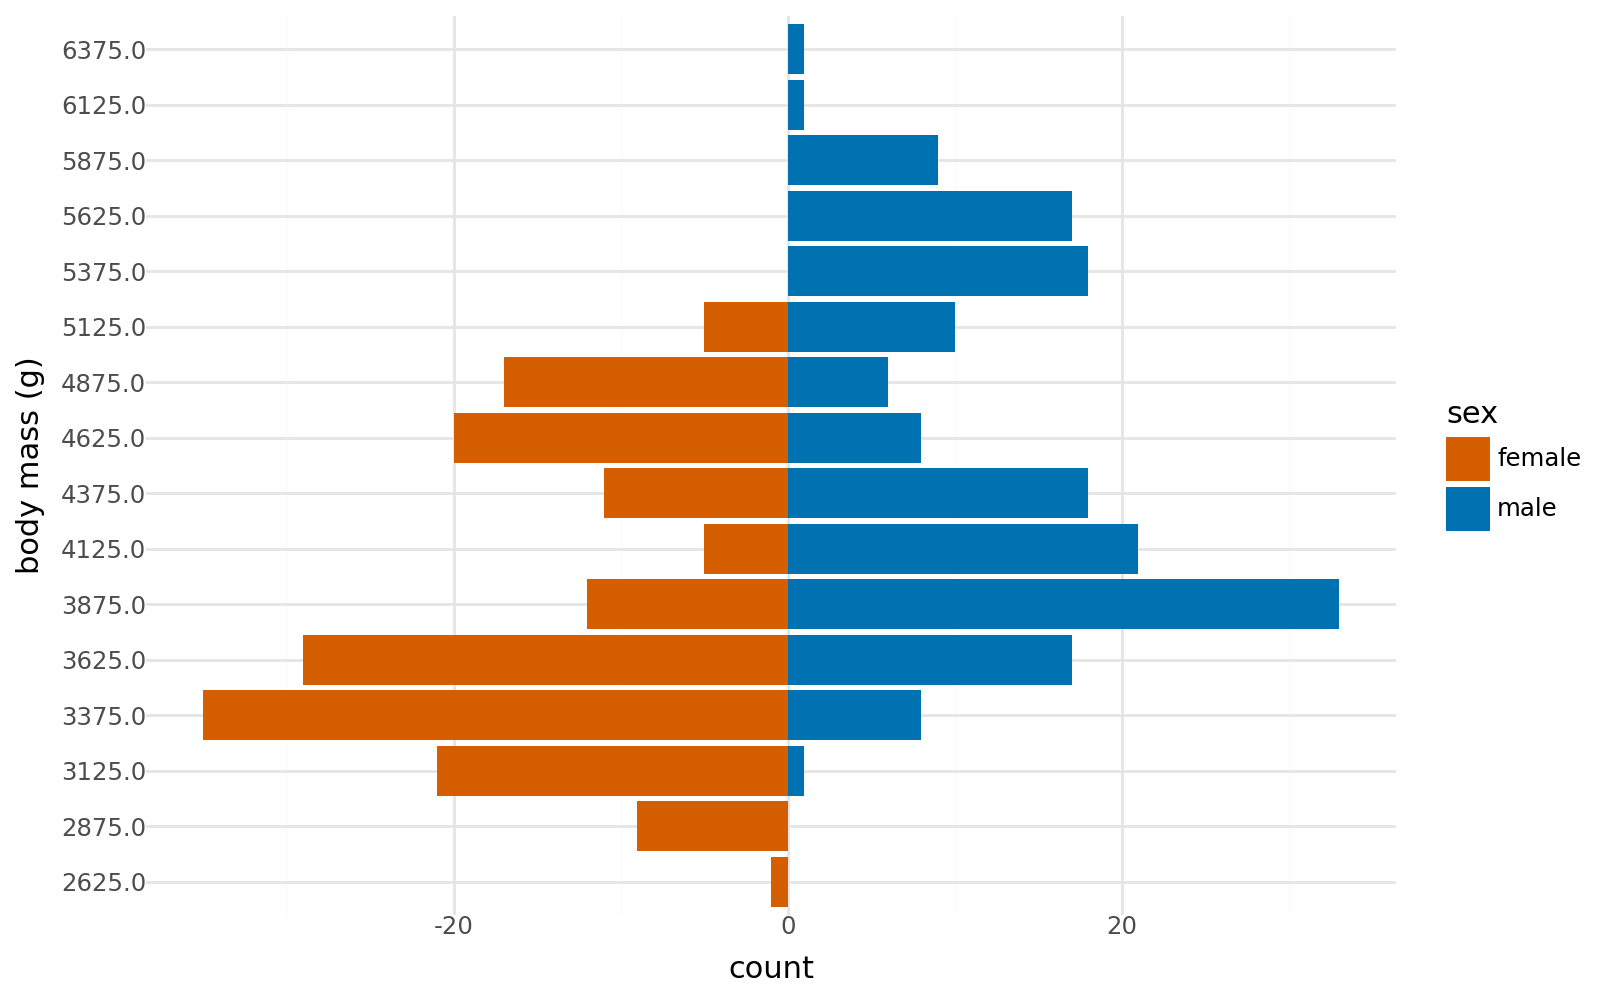

In [65]:
# ✏️ 보너스 문제 (선택)

# 수컷과 암컷의 몸무게 분포를 좌우로 비교한다.
# 암컷의 개수에 -1을 곱해 왼쪽에 표시한다.

bins = np.arange(2500, 6501, 250)

pyramid = peng.copy()

pyramid["mass_bin"] = pd.cut(
    pyramid["body_mass_g"],
    bins=bins
)

pyramid = (
    pyramid.groupby(
        ["mass_bin", "sex"],
        observed=True
    )
    .size()
    .reset_index(name="count")
)

pyramid["mass_mid"] = pyramid["mass_bin"].apply(
    lambda x: x.mid
).astype(float)

pyramid["plot_count"] = np.where(
    pyramid["sex"] == "female",
    -pyramid["count"],
    pyramid["count"]
)

(
    ggplot(
        pyramid,
        aes(
            x="factor(mass_mid)",
            y="plot_count",
            fill="sex"
        )
    )
    + geom_col()
    + coord_flip()
    + scale_fill_manual(
        values={
            "male": "#0072B2",
            "female": "#D55E00"
        }
    )
    + labs(
        x="body mass (g)",
        y="count",
        fill="sex"
    )
    + theme(figure_size=(8, 5))
)


## 6. 종합 문제 📝

`plotnine.data`의 데이터셋 중 **하나를 골라** 세션에서 배운 원칙을 적용한 그래프를 **1개 이상** 그리세요.
사용 가능한 데이터셋 예시: `diamonds`, `economics`, `msleep`, `mpg`, `midwest`, `penguins`, `txhousing` 등

그래프 아래에 다음 내용을 적어 주세요.
1. 어떤 질문에 답하려는 그래프인가요?
2. 데이터 종류(수량 / 분포 등)에 맞춰 **어떤 도표**를 골랐고, 그 이유는 무엇인가요?
3. **위치 스케일**(선형 / 로그 등)과 **색상 스케일**(정성적 / 순차적 / 발산형 / 강조)을 어떻게 선택했나요?
4. 세션에서 본 *ugly / bad / wrong* 사례 중 피하려고 신경 쓴 부분이 있다면 적어 주세요.

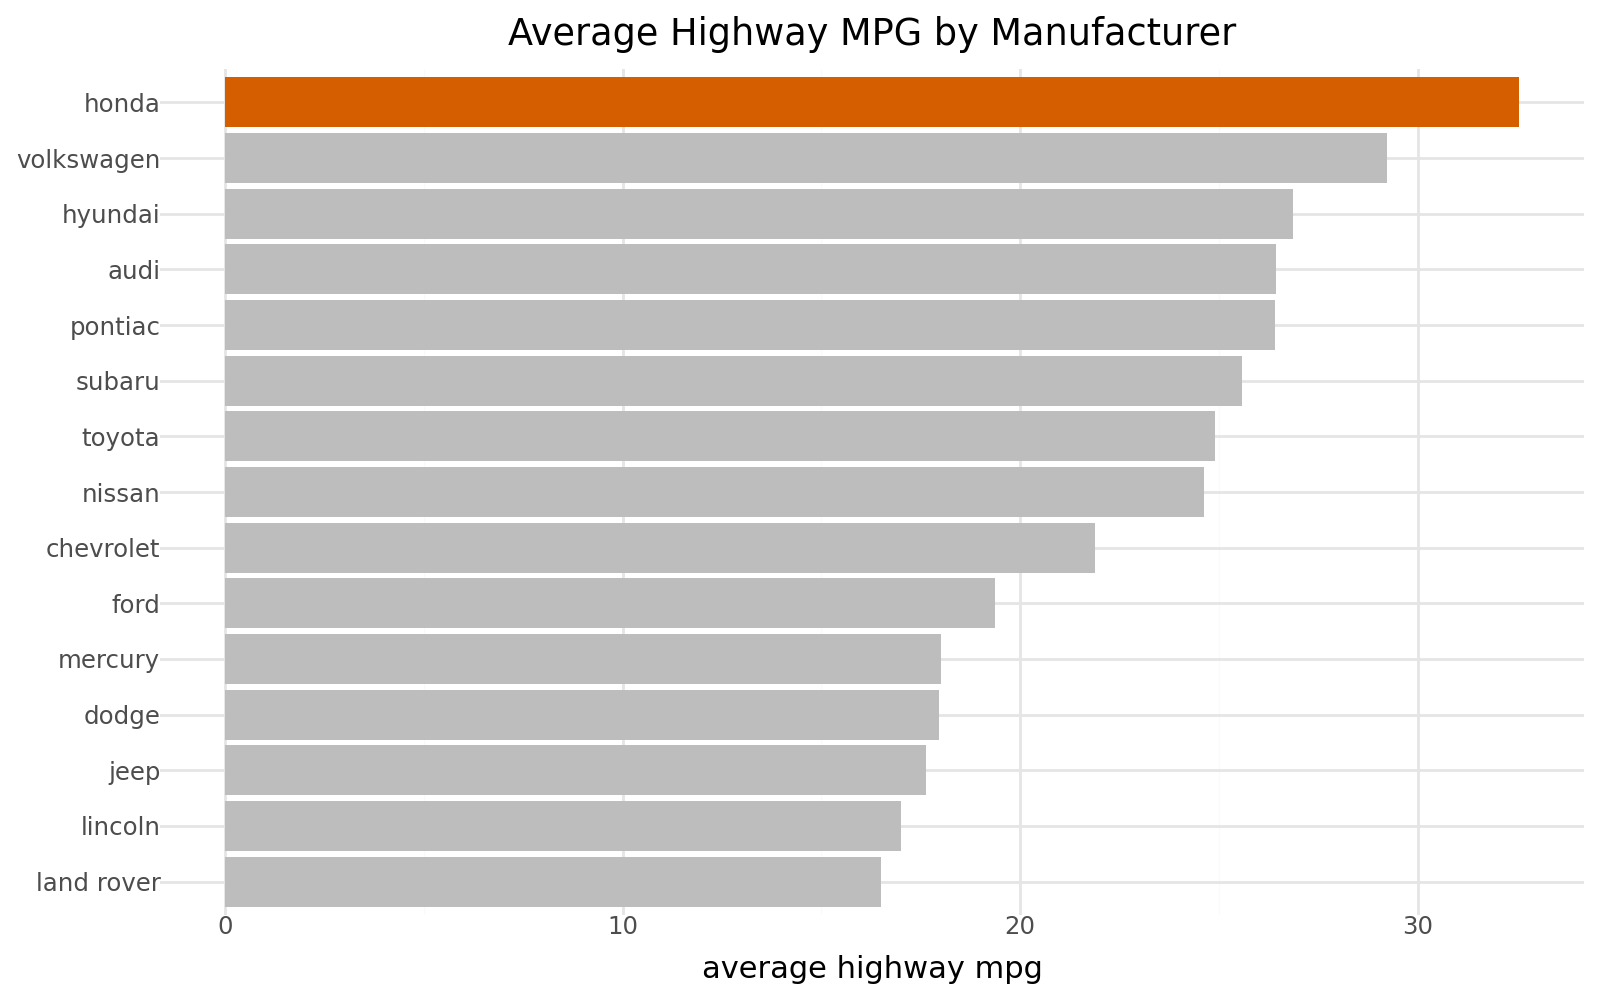

In [66]:
# ✏️ 자유롭게 작성하세요


# 제조사별 평균 고속도로 연비를 비교한다.
# 가장 연비가 높은 제조사는 주황색으로 강조하고,
# 나머지 제조사는 회색으로 표현한다.

summary = (
    mpg.groupby(
        "manufacturer",
        as_index=False,
        observed=True
    )["hwy"]
    .mean()
)

best_maker = summary.loc[
    summary["hwy"].idxmax(),
    "manufacturer"
]

summary["highlight"] = np.where(
    summary["manufacturer"] == best_maker,
    "Best",
    "Other"
)

(
    ggplot(
        summary,
        aes(
            x="reorder(manufacturer, hwy)",
            y="hwy",
            fill="highlight"
        )
    )
    + geom_col()
    + coord_flip()
    + scale_fill_manual(
        values={
            "Best": "#D55E00",
            "Other": "#BDBDBD"
        },
        guide=None
    )
    + labs(
        title="Average Highway MPG by Manufacturer",
        x="",
        y="average highway mpg"
    )
    + theme(figure_size=(8, 5))
)


**✍️ 답:** 1번, 자동차 제조사별 평균 고속도로 연비 차이와 가장 연비가 높은 제조사 어디인지 알아보기 위한 그래프이다. 2번, 제조사별 평균 연비는 범주에 따른 수량 데이터이므로 막대 그래프를 선택했다. 3번, 평균 연비는 양수이며 값의 크기를 직접 비교해야 하므로 선형 스케일을 사용했다. 색상은 가장 연비가 높은 제조사를 강조하고 나머지는 회색으로 표현하는 강조 스케일을 사용했다. 4번,축을 0부터 시작해 값의 차이가 과장되지 않도록 하고, 색상을 최소화하며 연비순으로 정렬해 가독성을 높였다.

## ⚙️ 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (여기에 답)

- **AI가 이 실험에는 틀린 답을 준 사례**
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

- **실제 대화 내역** 붙여넣기:

```
(여기에 AI와의 실제 대화 내역을 붙여넣기)
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은 무엇이었나요? (여기에 답)

---
### 수고하셨습니다! 🎉
제출 전 **런타임 → 모두 실행**으로 모든 셀이 에러 없이 실행되는지 확인해 주세요.